In [ ]:
# ============================================================
# PHẦN 0: MOUNT GOOGLE DRIVE & CÀI ĐẶT THƯ VIỆN
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/dataset_dl'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Thư mục lưu model: {SAVE_DIR}")

# Cài đặt thư viện cần thiết
!pip install -q tensorflow scikit-learn matplotlib seaborn pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, f1_score,
                             precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Thư mục lưu model: /content/drive/MyDrive/dataset_dl
TensorFlow version: 2.19.0
GPU available: []


## TẢI VÀ PHÂN TÍCH DỮ LIỆU

In [ ]:
# ============================================================
# PHẦN 1: TẢI VÀ KHÁM PHÁ DỮ LIỆU
# ============================================================

DATA_PATH = '/content/drive/MyDrive/dataset_dl/spam_ham_dataset.csv'
df = pd.read_csv(DATA_PATH)

print("=" * 60)
print("📊 THÔNG TIN TỔNG QUAN VỀ DATASET")
print("=" * 60)
print(f"\n📌 Kích thước dataset: {df.shape[0]} mẫu, {df.shape[1]} cột")
print(f"\n📌 Các cột trong dataset:")
print(df.dtypes)
print(f"\n📌 5 mẫu đầu tiên:")
df.head()

📊 THÔNG TIN TỔNG QUAN VỀ DATASET

📌 Kích thước dataset: 5171 mẫu, 4 cột

📌 Các cột trong dataset:
Unnamed: 0     int64
label         object
text          object
label_num      int64
dtype: object

📌 5 mẫu đầu tiên:


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


📊 THỐNG KÊ SỐ LƯỢNG MẪU THEO LỚP

📌 Phân bố lớp:
   Ham  (không spam): 3672 mẫu (71.0%)
   Spam (thư rác)   : 1499 mẫu (29.0%)
   Tỷ lệ Ham:Spam   = 2.45:1

⚠️  Dataset MẤT CÂN BẰNG: Lớp ham nhiều gấp ~2.4 lần lớp spam


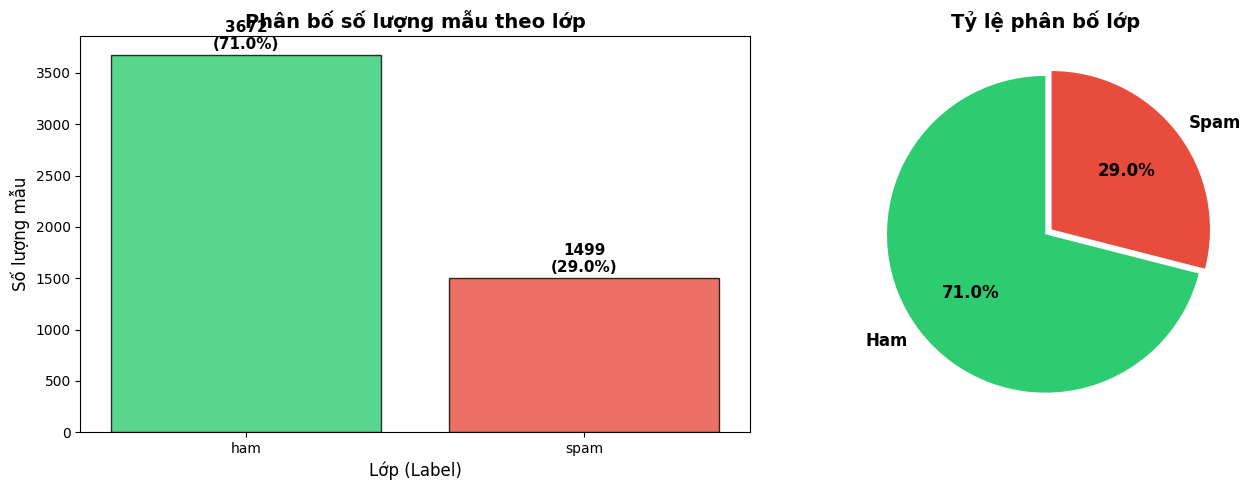


📊 THỐNG KÊ ĐỘ DÀI VĂN BẢN (SỐ TỪ)

📌 Lớp HAM:
   Min: 2, Max: 8862
   Mean: 225.2, Median: 123.0
   Std: 332.1
   Quantile 25%: 50, 75%: 293, 95%: 733

📌 Lớp SPAM:
   Min: 1, Max: 3962
   Mean: 234.1, Median: 114.0
   Std: 345.4
   Quantile 25%: 54, 75%: 242, 95%: 884


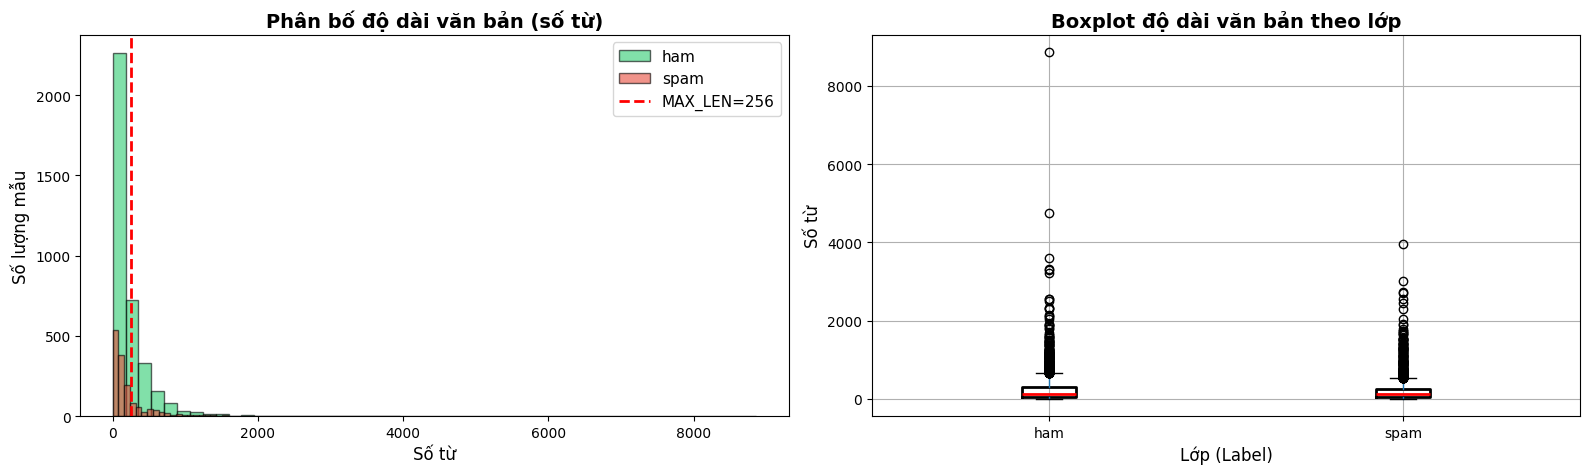


📊 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

📌 Dữ liệu thiếu (null):
Unnamed: 0     0
label          0
text           0
label_num      0
text_length    0
char_length    0
dtype: int64

📌 Số mẫu trùng lặp: 178

📌 Nhận xét các khó khăn đặc thù:
   1. ⚠️  Mất cân bằng lớp: Ham (71%) >> Spam (29%) → Cần class weight
   2. ⚠️  Độ dài chuỗi biến thiên lớn → Cần padding/truncating
   3. ⚠️  Dữ liệu email chứa HTML tags, ký tự đặc biệt → Cần tiền xử lý
   4. ⚠️  Có thể có mẫu trùng lặp → Cần loại bỏ


In [ ]:
# ============================================================
# PHẦN 2: PHÂN TÍCH DỮ LIỆU CHI TIẾT (EDA)
# ============================================================

print("=" * 60)
print("📊 THỐNG KÊ SỐ LƯỢNG MẪU THEO LỚP")
print("=" * 60)

# 2.1 Thống kê phân bố lớp
class_counts = df['label'].value_counts()
print(f"\n📌 Phân bố lớp:")
print(f"   Ham  (không spam): {class_counts['ham']} mẫu ({class_counts['ham']/len(df)*100:.1f}%)")
print(f"   Spam (thư rác)   : {class_counts['spam']} mẫu ({class_counts['spam']/len(df)*100:.1f}%)")
print(f"   Tỷ lệ Ham:Spam   = {class_counts['ham']/class_counts['spam']:.2f}:1")
print(f"\n⚠️  Dataset MẤT CÂN BẰNG: Lớp ham nhiều gấp ~{class_counts['ham']/class_counts['spam']:.1f} lần lớp spam")

# 2.2 Biểu đồ phân bố lớp
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Phân bố số lượng mẫu theo lớp', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Lớp (Label)', fontsize=12)
axes[0].set_ylabel('Số lượng mẫu', fontsize=12)
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                f'{count}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Ham', 'Spam'], autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Tỷ lệ phân bố lớp', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 2.3 Phân tích độ dài chuỗi
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_length'] = df['text'].apply(lambda x: len(str(x)))

print("\n" + "=" * 60)
print("📊 THỐNG KÊ ĐỘ DÀI VĂN BẢN (SỐ TỪ)")
print("=" * 60)

for label in ['ham', 'spam']:
    subset = df[df['label'] == label]['text_length']
    print(f"\n📌 Lớp {label.upper()}:")
    print(f"   Min: {subset.min()}, Max: {subset.max()}")
    print(f"   Mean: {subset.mean():.1f}, Median: {subset.median():.1f}")
    print(f"   Std: {subset.std():.1f}")
    print(f"   Quantile 25%: {subset.quantile(0.25):.0f}, 75%: {subset.quantile(0.75):.0f}, 95%: {subset.quantile(0.95):.0f}")

# 2.4 Biểu đồ phân bố độ dài
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram theo số từ
for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['text_length']
    axes[0].hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='black')
axes[0].set_title('Phân bố độ dài văn bản (số từ)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Số từ', fontsize=12)
axes[0].set_ylabel('Số lượng mẫu', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].axvline(x=256, color='red', linestyle='--', linewidth=2, label='MAX_LEN=256')
axes[0].legend(fontsize=11)

# Boxplot
df.boxplot(column='text_length', by='label', ax=axes[1],
           boxprops=dict(linewidth=2), medianprops=dict(linewidth=2, color='red'))
axes[1].set_title('Boxplot độ dài văn bản theo lớp', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Lớp (Label)', fontsize=12)
axes[1].set_ylabel('Số từ', fontsize=12)
plt.suptitle('')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 2.5 Kiểm tra dữ liệu thiếu và trùng lặp
print("\n" + "=" * 60)
print("📊 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU")
print("=" * 60)
print(f"\n📌 Dữ liệu thiếu (null):")
print(df.isnull().sum())
print(f"\n📌 Số mẫu trùng lặp: {df.duplicated(subset=['text']).sum()}")
print(f"\n📌 Nhận xét các khó khăn đặc thù:")
print("   1. ⚠️  Mất cân bằng lớp: Ham (71%) >> Spam (29%) → Cần class weight")
print("   2. ⚠️  Độ dài chuỗi biến thiên lớn → Cần padding/truncating")
print("   3. ⚠️  Dữ liệu email chứa HTML tags, ký tự đặc biệt → Cần tiền xử lý")
print("   4. ⚠️  Có thể có mẫu trùng lặp → Cần loại bỏ")

## TIỀN XỬ LÝ DỮ LIỆU

In [ ]:
# ============================================================
# PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU
# ============================================================

print("=" * 60)
print("🔧 TIỀN XỬ LÝ DỮ LIỆU")
print("=" * 60)

# 3.1 Loại bỏ mẫu trùng lặp
df_clean = df.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"\n📌 Sau khi loại trùng lặp: {len(df_clean)} mẫu (loại {len(df) - len(df_clean)} mẫu)")

# 3.2 Hàm tiền xử lý văn bản email
def preprocess_email(text):
    """
    Tiền xử lý email:
    1. Loại bỏ HTML tags
    2. Loại bỏ URL
    3. Loại bỏ email addresses
    4. Loại bỏ số điện thoại
    5. Loại bỏ ký tự đặc biệt
    6. Chuyển về chữ thường
    7. Loại bỏ khoảng trắng thừa
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Loại bỏ prefix "Subject:" nếu có
    text = re.sub(r'^Subject:\s*', '', text, flags=re.IGNORECASE)

    # Loại bỏ HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # Loại bỏ URLs
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)

    # Loại bỏ email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Loại bỏ số điện thoại
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', ' ', text)

    # Chuyển về chữ thường
    text = text.lower()

    # Loại bỏ ký tự đặc biệt, giữ lại chữ cái và số
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # Loại bỏ số đứng riêng (không phải phần của từ)
    text = re.sub(r'\b\d+\b', '', text)

    # Loại bỏ khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Áp dụng tiền xử lý
df_clean['clean_text'] = df_clean['text'].apply(preprocess_email)

# Loại bỏ mẫu có text rỗng sau tiền xử lý
df_clean = df_clean[df_clean['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"📌 Sau tiền xử lý: {len(df_clean)} mẫu")

# Hiển thị ví dụ trước và sau tiền xử lý
print(f"\n📌 Ví dụ tiền xử lý:")
for i in range(3):
    print(f"\n--- Mẫu {i+1} ({df_clean.iloc[i]['label']}) ---")
    print(f"  Gốc : {df_clean.iloc[i]['text'][:150]}...")
    print(f"  Sạch: {df_clean.iloc[i]['clean_text'][:150]}...")

# Cập nhật thống kê sau tiền xử lý
df_clean['clean_text_length'] = df_clean['clean_text'].apply(lambda x: len(x.split()))
print(f"\n📌 Thống kê độ dài sau tiền xử lý:")
print(df_clean.groupby('label')['clean_text_length'].describe().round(1))

🔧 TIỀN XỬ LÝ DỮ LIỆU

📌 Sau khi loại trùng lặp: 4993 mẫu (loại 178 mẫu)
📌 Sau tiền xử lý: 4990 mẫu

📌 Ví dụ tiền xử lý:

--- Mẫu 1 (ham) ---
  Gốc : Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by dar...
  Sạch: enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume p...

--- Mẫu 2 (ham) ---
  Gốc : Subject: hpl nom for january 9 , 2001
( see attached file : hplnol 09 . xls )
- hplnol 09 . xls...
  Sạch: hpl nom for january see attached file hplnol xls hplnol xls...

--- Mẫu 3 (ham) ---
  Gốc : Subject: neon retreat
ho ho ho , we ' re around to that most wonderful time of the year - - - neon leaders retreat time !
i know that this time of y...
  Sạch: neon retreat ho ho ho we re around to that most wonderful time of the year neon leaders retreat time i know that this time of year is extremely hecti

In [ ]:
# ============================================================
# PHẦN 4: TOKENIZATION & CHIA TẬP DỮ LIỆU
# ============================================================

print("=" * 60)
print("🔧 TOKENIZATION & CHIA TẬP DỮ LIỆU")
print("=" * 60)

# 4.1 Cấu hình
MAX_WORDS = 20000   # Kích thước vocabulary
MAX_LEN = 256       # Độ dài tối đa chuỗi (theo yêu cầu đề bài)
EMBEDDING_DIM = 128 # Kích thước embedding vector

# 4.2 Tokenization
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df_clean['clean_text'])

# Thống kê vocabulary
word_index = tokenizer.word_index
print(f"\n📌 Tổng số từ vựng (unique words): {len(word_index)}")
print(f"📌 Số từ vựng sử dụng (MAX_WORDS): {MAX_WORDS}")

# Chuyển text thành sequences
sequences = tokenizer.texts_to_sequences(df_clean['clean_text'])

# Padding sequences
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df_clean['label_num'].values

print(f"\n📌 Kích thước X (padded sequences): {X.shape}")
print(f"📌 Kích thước y (labels): {y.shape}")

# 4.3 Thống kê coverage (bao nhiêu % từ được giữ lại)
total_words_in_sequences = sum(len(seq) for seq in sequences)
total_words_original = sum(len(text.split()) for text in df_clean['clean_text'])
print(f"\n📌 Tổng từ gốc: {total_words_original}")
print(f"📌 Tổng từ sau tokenize (trong vocabulary): {total_words_in_sequences}")

# 4.4 Chia tập train/validation/test (70/15/15)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=SEED, stratify=y_train_full
)
# 0.176 ≈ 15/85 → tỷ lệ 70/15/15

print(f"\n📌 Chia tập dữ liệu (stratified):")
print(f"   Train     : {X_train.shape[0]} mẫu ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]} mẫu ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test      : {X_test.shape[0]} mẫu ({X_test.shape[0]/len(X)*100:.1f}%)")

# Kiểm tra tỷ lệ lớp trong mỗi tập
for name, labels in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    spam_ratio = labels.sum() / len(labels) * 100
    ham_ratio = 100 - spam_ratio
    print(f"   {name:10s}: Ham={ham_ratio:.1f}%, Spam={spam_ratio:.1f}%")

# 4.5 Tính class weight để xử lý mất cân bằng
class_weights_array = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print(f"\n📌 Class weights (xử lý mất cân bằng):")
print(f"   Ham (0) : {class_weight_dict[0]:.4f}")
print(f"   Spam (1): {class_weight_dict[1]:.4f}")

# Lưu tokenizer để dùng cho demo sau này
import pickle
tokenizer_path = os.path.join(SAVE_DIR, 'tokenizer.pickle')
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f"\n✅ Đã lưu tokenizer tại: {tokenizer_path}")

🔧 TOKENIZATION & CHIA TẬP DỮ LIỆU

📌 Tổng số từ vựng (unique words): 45769
📌 Số từ vựng sử dụng (MAX_WORDS): 20000

📌 Kích thước X (padded sequences): (4990, 256)
📌 Kích thước y (labels): (4990,)

📌 Tổng từ gốc: 752727
📌 Tổng từ sau tokenize (trong vocabulary): 752727

📌 Chia tập dữ liệu (stratified):
   Train     : 3494 mẫu (70.0%)
   Validation: 747 mẫu (15.0%)
   Test      : 749 mẫu (15.0%)
   Train     : Ham=70.7%, Spam=29.3%
   Validation: Ham=70.8%, Spam=29.2%
   Test      : Ham=70.8%, Spam=29.2%

📌 Class weights (xử lý mất cân bằng):
   Ham (0) : 0.7067
   Spam (1): 1.7094

✅ Đã lưu tokenizer tại: /content/drive/MyDrive/dataset_dl/tokenizer.pickle


## MÔ HÌNH 1 - BASELINE

In [ ]:
# ============================================================
# PHẦN 5: MÔ HÌNH 1 - BASELINE: BiLSTM + Embedding + Pooling
# ============================================================

print("=" * 60)
print("🧠 MÔ HÌNH 1: BiLSTM + Embedding + GlobalMaxPooling (Baseline)")
print("=" * 60)

def build_bilstm_model(optimizer_name='adam', dropout_rate=0.5, use_weight_decay=False):
    """
    Mô hình Baseline: BiLSTM
    - Embedding layer
    - Bidirectional LSTM
    - Global Max Pooling
    - Dense layers với Dropout
    - Binary Cross-Entropy Loss
    """
    inputs = layers.Input(shape=(MAX_LEN,), name='input')

    # Embedding layer
    x = layers.Embedding(input_dim=MAX_WORDS,
                         output_dim=EMBEDDING_DIM,
                         input_length=MAX_LEN,
                         name='embedding')(inputs)

    # Spatial Dropout (regularization cho embedding)
    x = layers.SpatialDropout1D(0.2, name='spatial_dropout')(x)

    # Bidirectional LSTM
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, name='lstm'),
        name='bidirectional_lstm'
    )(x)

    # Global Max Pooling - lấy features quan trọng nhất
    x = layers.GlobalMaxPooling1D(name='global_max_pool')(x)

    # Dense layers
    x = layers.Dense(64, activation='relu', name='dense_1')(x)
    x = layers.Dropout(dropout_rate, name='dropout')(x)
    x = layers.Dense(32, activation='relu', name='dense_2')(x)

    # Output layer
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='BiLSTM_Baseline')

    # Chọn optimizer
    if optimizer_name == 'adam':
        if use_weight_decay:
            optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
        else:
            optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    elif optimizer_name == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )

    return model

# Xây dựng model
model_bilstm = build_bilstm_model(optimizer_name='adam', dropout_rate=0.5)
model_bilstm.summary()

# Đếm số lượng tham số
total_params = model_bilstm.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model_bilstm.trainable_weights])
print(f"\n📌 Tổng số tham số: {total_params:,}")
print(f"📌 Số tham số trainable: {trainable_params:,}")

🧠 MÔ HÌNH 1: BiLSTM + Embedding + GlobalMaxPooling (Baseline)


Model: "BiLSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 256, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 256, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm              │ (None, 256, 256)       │       263,168 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pool                 │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,841,729 (10.84 MB)

 Trainable params: 2,841,729 (10.84 MB)

 Non-trainable params: 0 (0.00 B)


📌 Tổng số tham số: 2,841,729
📌 Số tham số trainable: 2,841,729


In [ ]:
# ============================================================
# PHẦN 6: HUẤN LUYỆN MÔ HÌNH 1 - BiLSTM
# ============================================================

print("=" * 60)
print("🚀 HUẤN LUYỆN MÔ HÌNH 1: BiLSTM (Adam + Dropout)")
print("=" * 60)

# Callbacks
BILSTM_MODEL_PATH = os.path.join(SAVE_DIR, 'bilstm_baseline.keras')

callbacks_bilstm = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BILSTM_MODEL_PATH, monitor='val_loss',
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

# Huấn luyện
EPOCHS = 30
BATCH_SIZE = 32

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_bilstm,
    verbose=1
)

print(f"\n✅ Model BiLSTM đã lưu tại: {BILSTM_MODEL_PATH}")

🚀 HUẤN LUYỆN MÔ HÌNH 1: BiLSTM (Adam + Dropout)
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 923ms/step - accuracy: 0.7820 - loss: 0.5487 - precision: 0.6159 - recall: 0.4448
Epoch 1: val_loss improved from None to 0.14590, saving model to /content/drive/MyDrive/dataset_dl/bilstm_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_dl/bilstm_baseline.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.8572 - loss: 0.3828 - precision: 0.7666 - recall: 0.7358 - val_accuracy: 0.9505 - val_loss: 0.1459 - val_precision: 0.8851 - val_recall: 0.9541 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.9600 - loss: 0.1177 - precision: 0.9078 - recall: 0.9574
Epoch 2: val_loss improved from 0.14590 to 0.10545, saving model to /content/drive/MyDrive/dataset_dl/bilstm_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_dl/bilstm_baseline.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 126s 920ms/step - accu

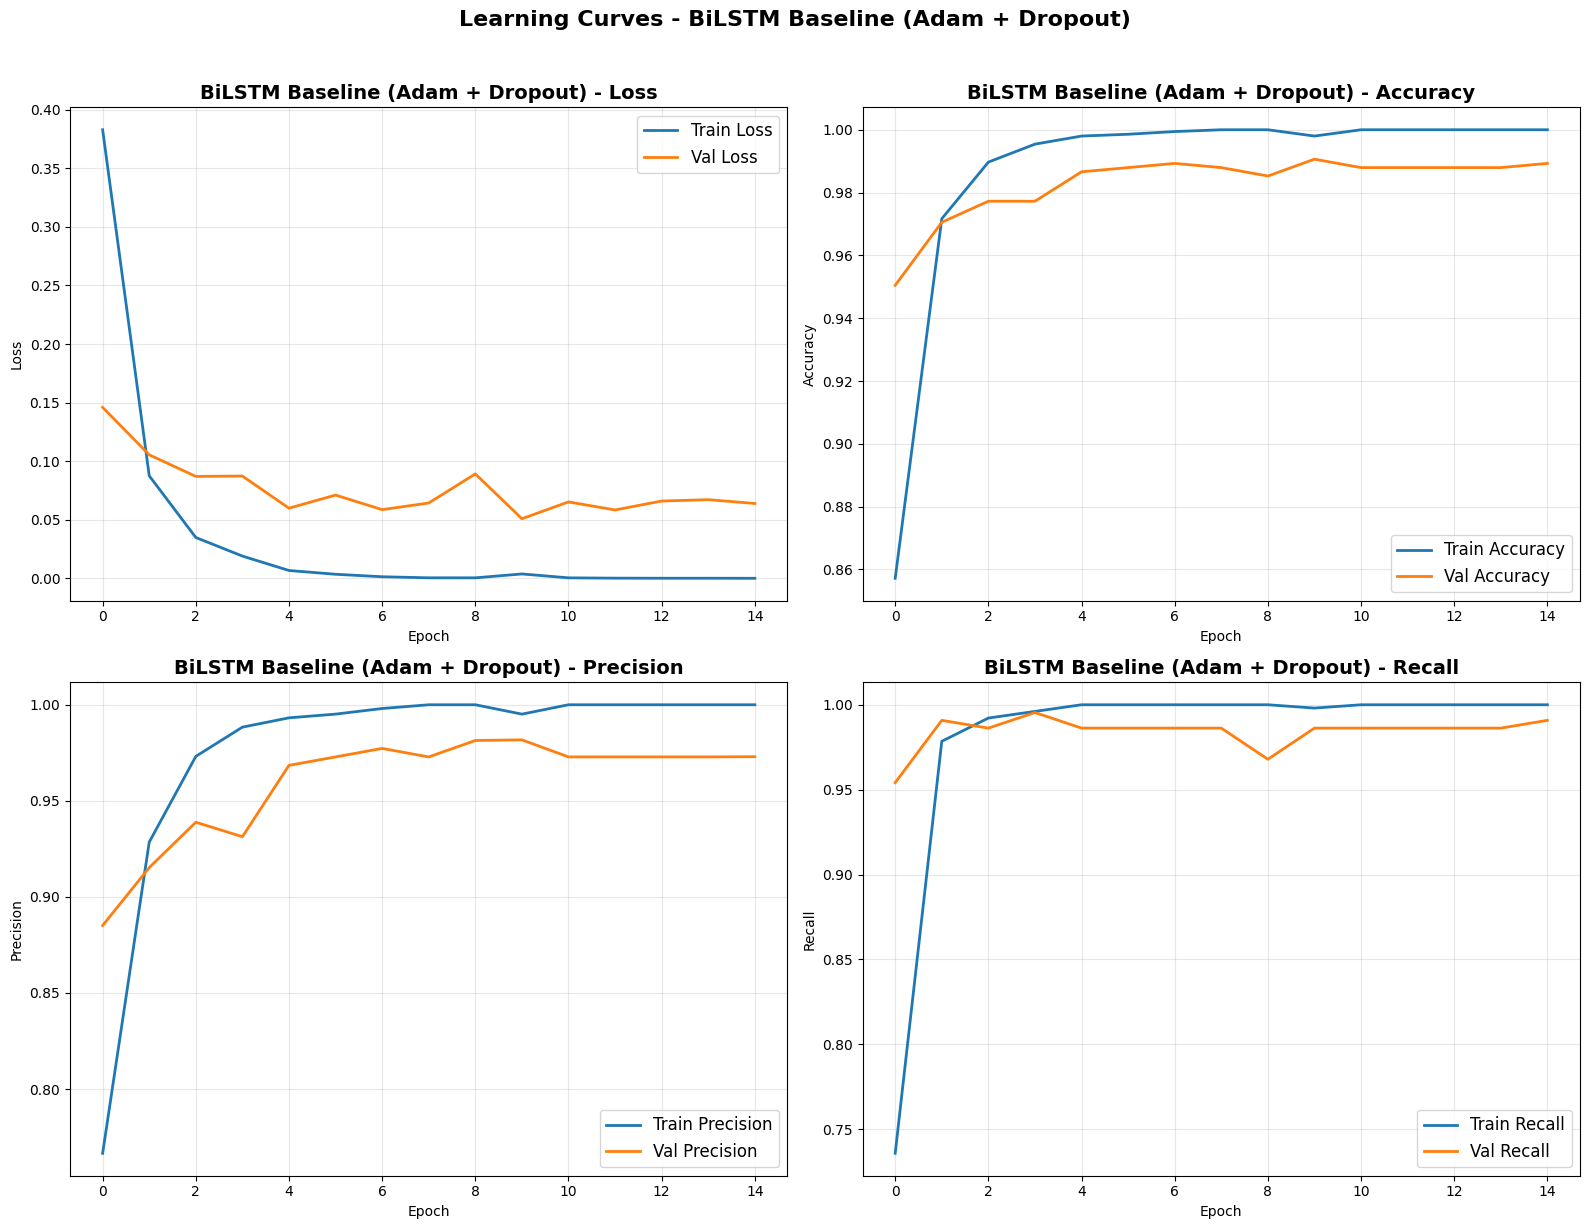

In [ ]:
# ============================================================
# PHẦN 7: VẼ LEARNING CURVES - MÔ HÌNH 1
# ============================================================

def plot_learning_curves(history, model_name, save_path=None):
    """Vẽ learning curves cho loss và các metrics"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Loss
    axes[0, 0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0, 0].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend(fontsize=12)
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0, 1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0, 1].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend(fontsize=12)
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Precision
    axes[1, 0].plot(history.history['precision'], label='Train Precision', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', linewidth=2)
    axes[1, 0].set_title(f'{model_name} - Precision', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend(fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Recall
    axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2)
    axes[1, 1].set_title(f'{model_name} - Recall', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend(fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'Learning Curves - {model_name}', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_learning_curves(history_bilstm, 'BiLSTM Baseline (Adam + Dropout)',
                     save_path=f'{SAVE_DIR}/learning_curves_bilstm.png')


📊 ĐÁNH GIÁ BiLSTM Baseline TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9981    0.9868    0.9924       530
    Spam (1)     0.9689    0.9954    0.9820       219

    accuracy                         0.9893       749
   macro avg     0.9835    0.9911    0.9872       749
weighted avg     0.9896    0.9893    0.9894       749

📌 Accuracy : 0.9893
📌 Precision: 0.9689
📌 Recall   : 0.9954  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9820


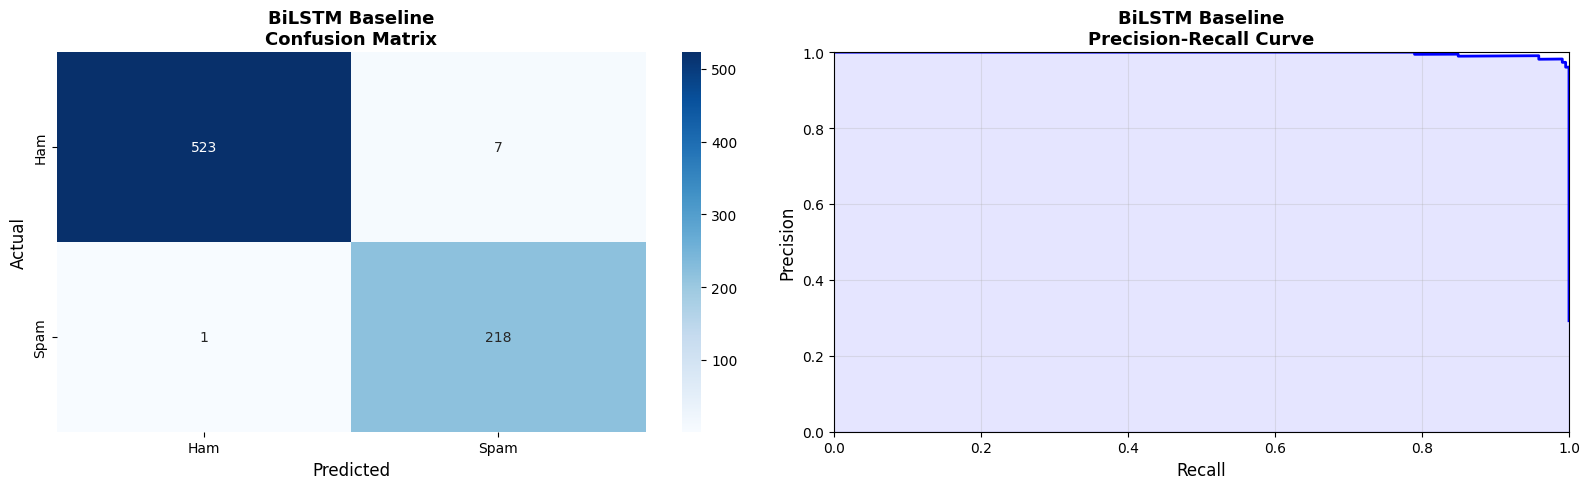

In [ ]:
# ============================================================
# PHẦN 8: ĐÁNH GIÁ MÔ HÌNH 1 TRÊN TẬP TEST
# ============================================================

def evaluate_model(model, X_test, y_test, model_name, save_path=None):
    """Đánh giá model toàn diện trên tập test"""
    # Predict
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    # Classification Report
    print(f"\n{'='*60}")
    print(f"📊 ĐÁNH GIÁ {model_name} TRÊN TẬP TEST")
    print(f"{'='*60}")

    print(f"\n📌 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)'], digits=4))

    # Metrics quan trọng
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"📌 Accuracy : {acc:.4f}")
    print(f"📌 Precision: {prec:.4f}")
    print(f"📌 Recall   : {rec:.4f}  ← ƯU TIÊN (phát hiện spam)")
    print(f"📌 F1-Score : {f1:.4f}")

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Actual', fontsize=12)
    axes[0].set_xlabel('Predicted', fontsize=12)

    # Precision-Recall Curve
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_pred_prob)
    axes[1].plot(recall_vals, precision_vals, linewidth=2, color='blue')
    axes[1].fill_between(recall_vals, precision_vals, alpha=0.1, color='blue')
    axes[1].set_title(f'{model_name}\nPrecision-Recall Curve', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Recall', fontsize=12)
    axes[1].set_ylabel('Precision', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

results_bilstm = evaluate_model(model_bilstm, X_test, y_test, 'BiLSTM Baseline',
                                 save_path=f'{SAVE_DIR}/eval_bilstm.png')

## THÍ NGHIỆM SO SÁNH OPTIMIZER & REGULARIZATION

🔬 THÍ NGHIỆM: BiLSTM với SGD Optimizer
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.4458 - loss: 0.6888 - precision: 0.3037 - recall: 0.7037
Epoch 1: val_loss improved from None to 0.67512, saving model to /content/drive/MyDrive/dataset_dl/bilstm_sgd.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_dl/bilstm_sgd.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.4840 - loss: 0.6903 - precision: 0.3166 - recall: 0.6595 - val_accuracy: 0.7805 - val_loss: 0.6751 - val_precision: 0.9091 - val_recall: 0.2752 - learning_rate: 0.0100
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 852ms/step - accuracy: 0.7421 - loss: 0.6676 - precision: 0.5696 - recall: 0.5162
Epoch 2: val_loss improved from 0.67512 to 0.55790, saving model to /content/drive/MyDrive/dataset_dl/bilstm_sgd.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_dl/bilstm_sgd.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 129s 949ms/step - accuracy: 0.7244 - loss: 0.6484 -

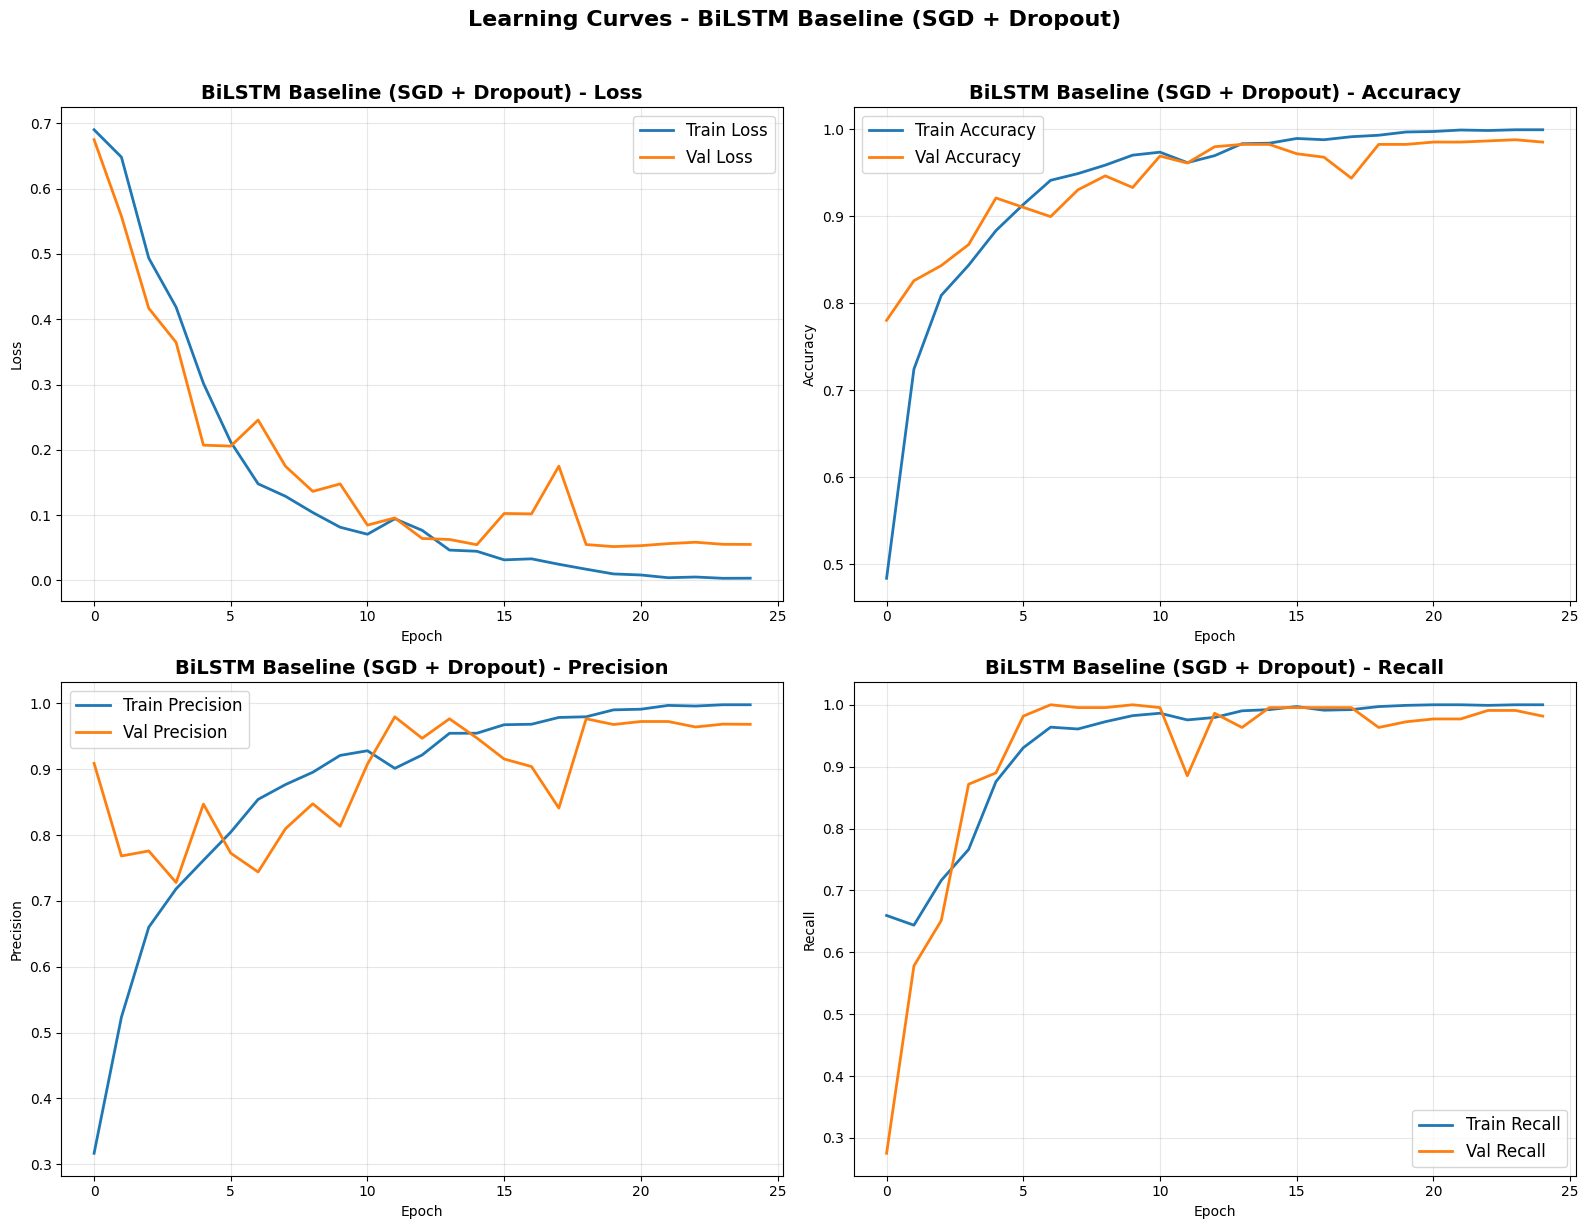


📊 ĐÁNH GIÁ BiLSTM (SGD) TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9962    0.9849    0.9905       530
    Spam (1)     0.9644    0.9909    0.9775       219

    accuracy                         0.9866       749
   macro avg     0.9803    0.9879    0.9840       749
weighted avg     0.9869    0.9866    0.9867       749

📌 Accuracy : 0.9866
📌 Precision: 0.9644
📌 Recall   : 0.9909  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9775


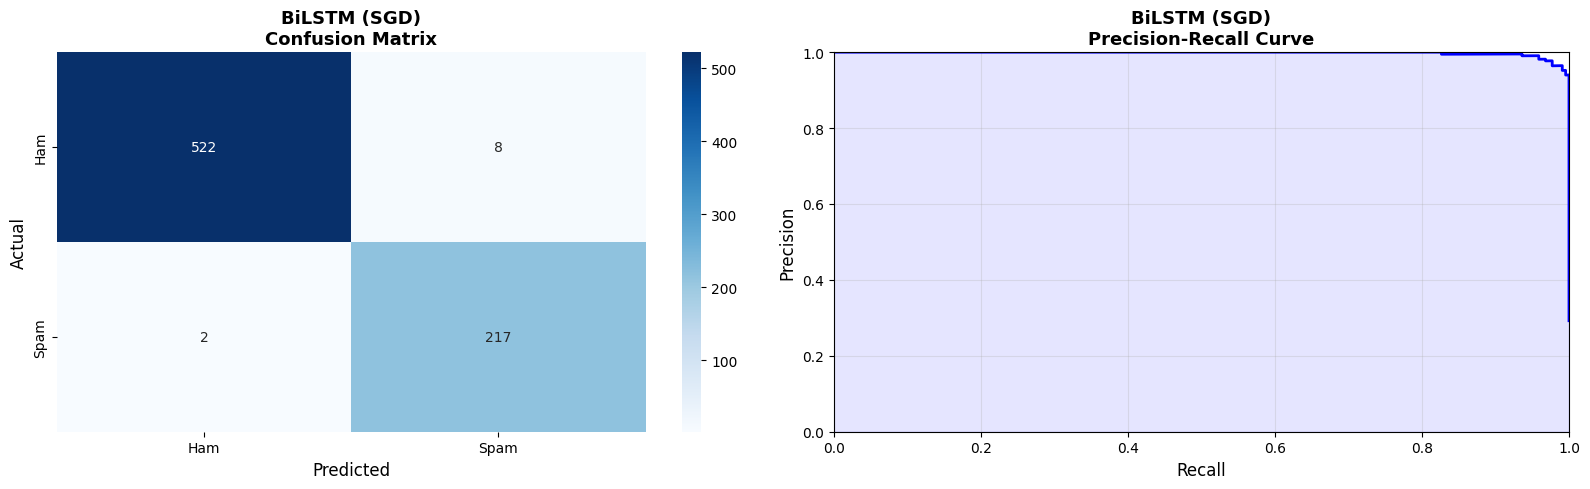

In [ ]:
# ============================================================
# PHẦN 9: THÍ NGHIỆM 1 - SO SÁNH OPTIMIZER (SGD vs Adam)
# ============================================================

print("=" * 60)
print("🔬 THÍ NGHIỆM: BiLSTM với SGD Optimizer")
print("=" * 60)

model_bilstm_sgd = build_bilstm_model(optimizer_name='sgd', dropout_rate=0.5)

BILSTM_SGD_PATH = os.path.join(SAVE_DIR, 'bilstm_sgd.keras')
callbacks_sgd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BILSTM_SGD_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

history_bilstm_sgd = model_bilstm_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_sgd,
    verbose=1
)

plot_learning_curves(history_bilstm_sgd, 'BiLSTM Baseline (SGD + Dropout)',
                     save_path=f'{SAVE_DIR}/learning_curves_bilstm_sgd.png')

results_bilstm_sgd = evaluate_model(model_bilstm_sgd, X_test, y_test, 'BiLSTM (SGD)',
                                     save_path=f'{SAVE_DIR}/eval_bilstm_sgd.png')

🔬 THÍ NGHIỆM: BiLSTM với Weight Decay (thay vì Dropout)
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.8004 - loss: 0.4544 - precision: 0.6302 - recall: 0.8516
Epoch 1: val_loss improved from None to 0.15109, saving model to /content/drive/MyDrive/dataset_dl/bilstm_weight_decay.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_dl/bilstm_weight_decay.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 105s 911ms/step - accuracy: 0.8781 - loss: 0.3103 - precision: 0.7427 - recall: 0.8924 - val_accuracy: 0.9451 - val_loss: 0.1511 - val_precision: 0.9116 - val_recall: 0.8991 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.9637 - loss: 0.1015 - precision: 0.9104 - recall: 0.9690
Epoch 2: val_loss improved from 0.15109 to 0.06004, saving model to /content/drive/MyDrive/dataset_dl/bilstm_weight_decay.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_dl/bilstm_weight_decay.keras
110/110 ━━━━━━━━━━━━━━━━

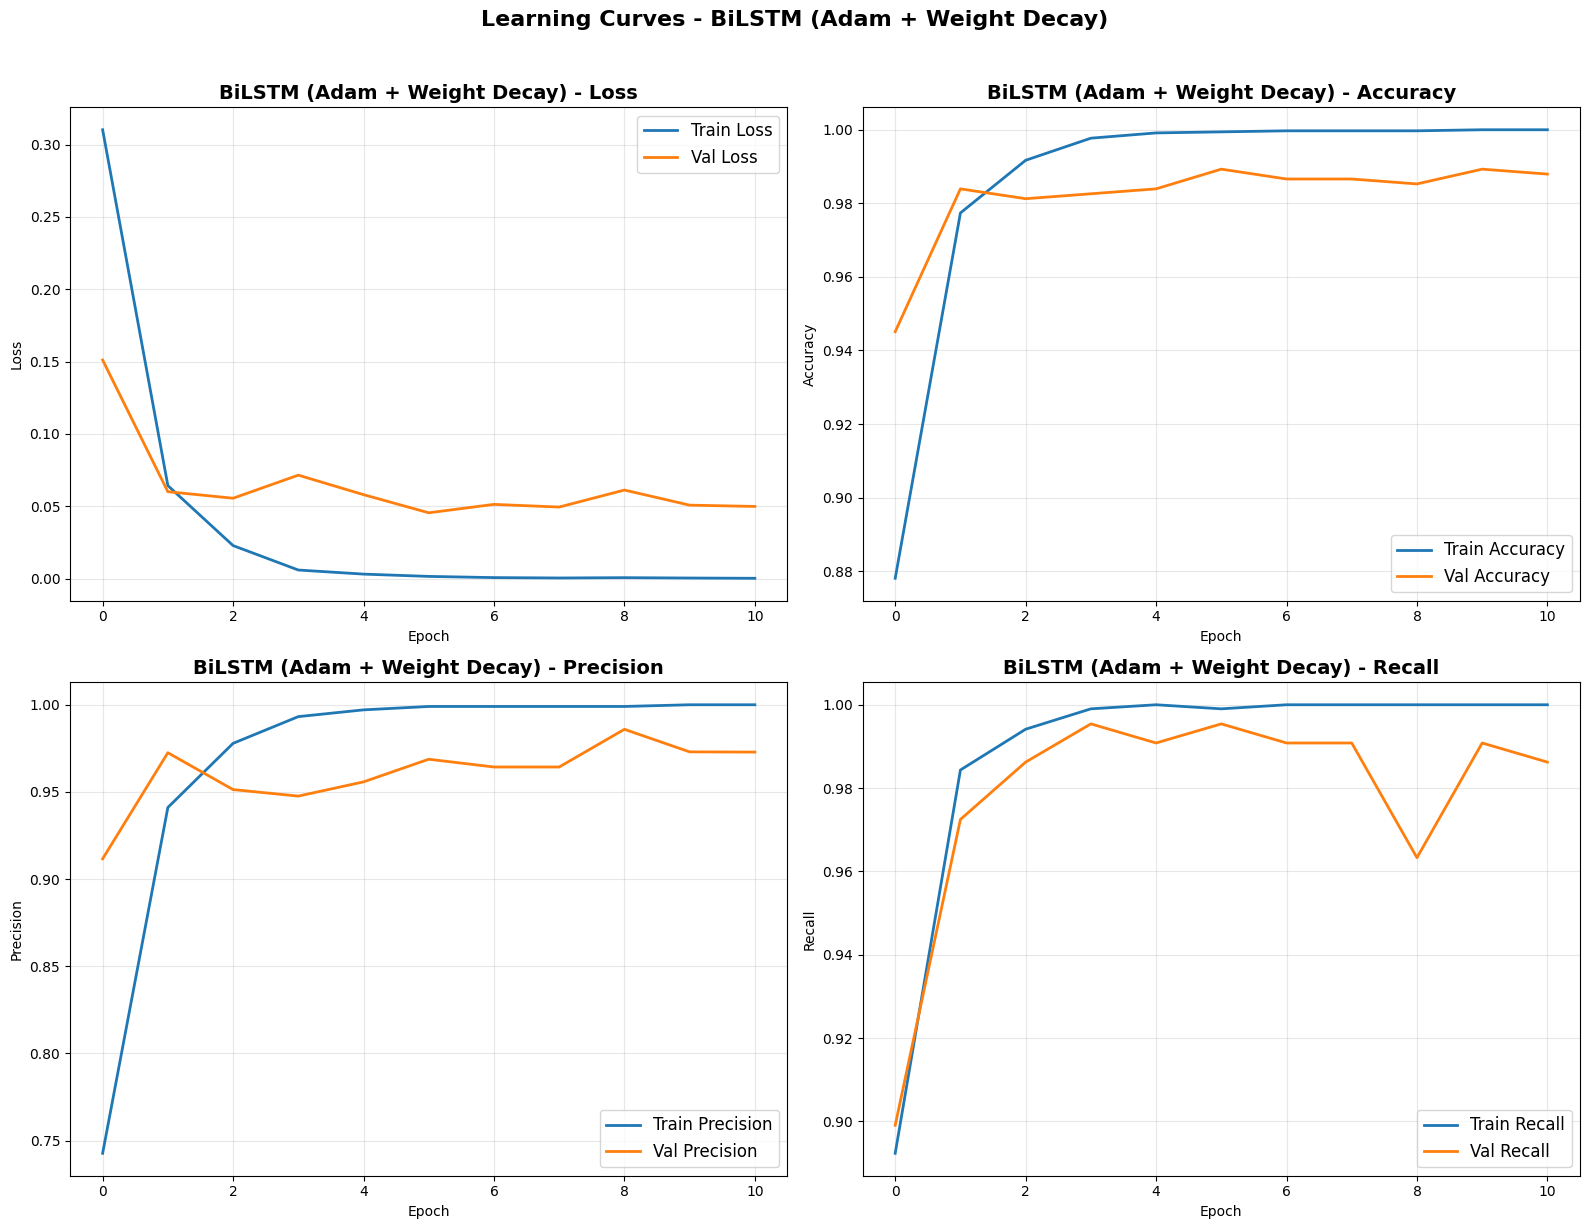


📊 ĐÁNH GIÁ BiLSTM (Weight Decay) TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9981    0.9830    0.9905       530
    Spam (1)     0.9604    0.9954    0.9776       219

    accuracy                         0.9866       749
   macro avg     0.9792    0.9892    0.9840       749
weighted avg     0.9871    0.9866    0.9867       749

📌 Accuracy : 0.9866
📌 Precision: 0.9604
📌 Recall   : 0.9954  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9776


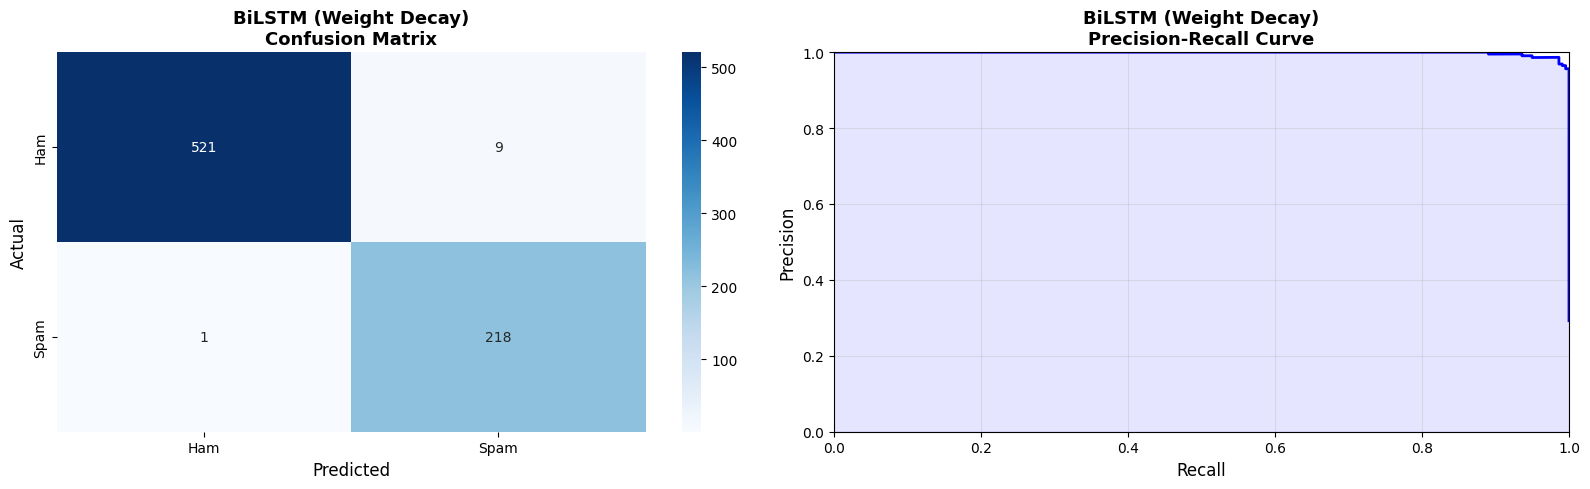

In [ ]:
# ============================================================
# PHẦN 10: THÍ NGHIỆM 2 - SO SÁNH REGULARIZATION
#           (Dropout vs Weight Decay)
# ============================================================

print("=" * 60)
print("🔬 THÍ NGHIỆM: BiLSTM với Weight Decay (thay vì Dropout)")
print("=" * 60)

model_bilstm_wd = build_bilstm_model(optimizer_name='adam', dropout_rate=0.0, use_weight_decay=True)

BILSTM_WD_PATH = os.path.join(SAVE_DIR, 'bilstm_weight_decay.keras')
callbacks_wd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BILSTM_WD_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

history_bilstm_wd = model_bilstm_wd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_wd,
    verbose=1
)

plot_learning_curves(history_bilstm_wd, 'BiLSTM (Adam + Weight Decay)',
                     save_path=f'{SAVE_DIR}/learning_curves_bilstm_wd.png')

results_bilstm_wd = evaluate_model(model_bilstm_wd, X_test, y_test, 'BiLSTM (Weight Decay)',
                                    save_path=f'{SAVE_DIR}/eval_bilstm_wd.png')

📊 BẢNG SO SÁNH CÁC THÍ NGHIỆM - MÔ HÌNH 1 (BiLSTM)
                     Mô hình          Optimizer    Regularization Accuracy Precision Recall (Spam) F1-Score
     BiLSTM (Adam + Dropout)               Adam       Dropout=0.5   0.9893    0.9689        0.9954   0.9820
      BiLSTM (SGD + Dropout) SGD (momentum=0.9)       Dropout=0.5   0.9866    0.9644        0.9909   0.9775
BiLSTM (Adam + Weight Decay)    AdamW (wd=1e-4) Weight Decay=1e-4   0.9866    0.9604        0.9954   0.9776


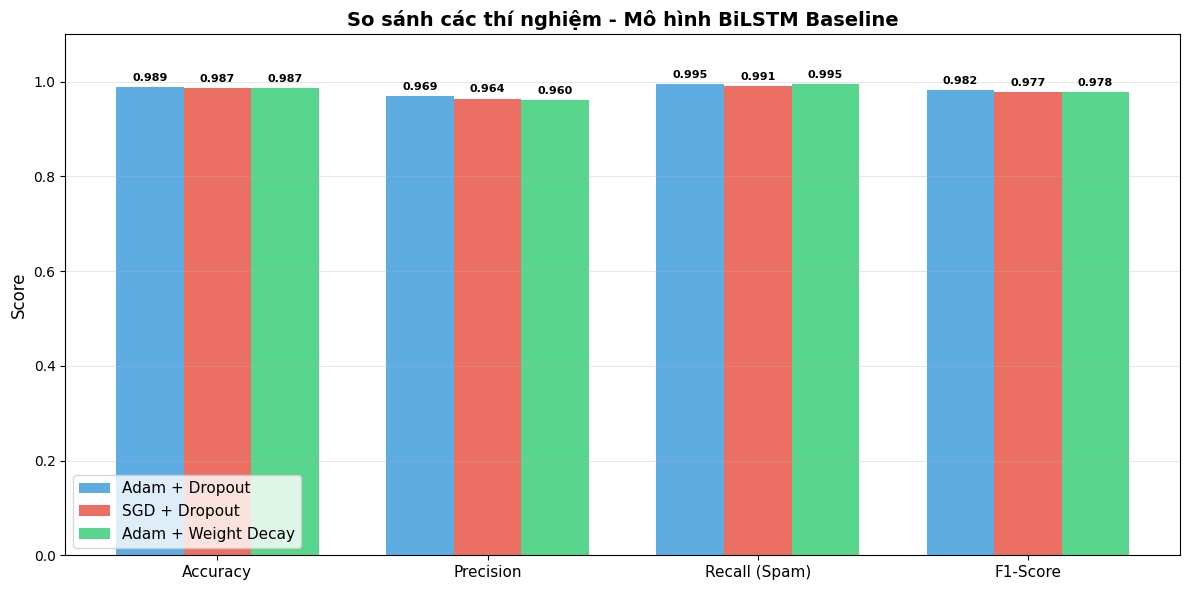

In [ ]:
# ============================================================
# PHẦN 11: BẢNG SO SÁNH CÁC THÍ NGHIỆM
# ============================================================

print("=" * 60)
print("📊 BẢNG SO SÁNH CÁC THÍ NGHIỆM - MÔ HÌNH 1 (BiLSTM)")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Mô hình': ['BiLSTM (Adam + Dropout)', 'BiLSTM (SGD + Dropout)', 'BiLSTM (Adam + Weight Decay)'],
    'Optimizer': ['Adam', 'SGD (momentum=0.9)', 'AdamW (wd=1e-4)'],
    'Regularization': ['Dropout=0.5', 'Dropout=0.5', 'Weight Decay=1e-4'],
    'Accuracy': [results_bilstm['accuracy'], results_bilstm_sgd['accuracy'], results_bilstm_wd['accuracy']],
    'Precision': [results_bilstm['precision'], results_bilstm_sgd['precision'], results_bilstm_wd['precision']],
    'Recall (Spam)': [results_bilstm['recall'], results_bilstm_sgd['recall'], results_bilstm_wd['recall']],
    'F1-Score': [results_bilstm['f1'], results_bilstm_sgd['f1'], results_bilstm_wd['f1']],
})

# Format numbers
for col in ['Accuracy', 'Precision', 'Recall (Spam)', 'F1-Score']:
    comparison_df[col] = comparison_df[col].apply(lambda x: f'{x:.4f}')

print(comparison_df.to_string(index=False))

# Vẽ biểu đồ so sánh
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(4)
width = 0.25
metrics = ['Accuracy', 'Precision', 'Recall (Spam)', 'F1-Score']
values_adam = [results_bilstm['accuracy'], results_bilstm['precision'],
               results_bilstm['recall'], results_bilstm['f1']]
values_sgd = [results_bilstm_sgd['accuracy'], results_bilstm_sgd['precision'],
              results_bilstm_sgd['recall'], results_bilstm_sgd['f1']]
values_wd = [results_bilstm_wd['accuracy'], results_bilstm_wd['precision'],
             results_bilstm_wd['recall'], results_bilstm_wd['f1']]

bars1 = ax.bar(x - width, values_adam, width, label='Adam + Dropout', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, values_sgd, width, label='SGD + Dropout', color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + width, values_wd, width, label='Adam + Weight Decay', color='#2ecc71', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('So sánh các thí nghiệm - Mô hình BiLSTM Baseline', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Thêm giá trị lên mỗi bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/comparison_experiments_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## MÔ HÌNH 2 - NÂNG CAO (BiGRU + Attention)

In [ ]:
# ============================================================
# PHẦN 12: CUSTOM ATTENTION LAYER
# ============================================================

print("=" * 60)
print("🧠 ĐỊNH NGHĨA ATTENTION LAYER")
print("=" * 60)

class AttentionLayer(layers.Layer):
    """
    Attention mechanism cho sequence classification.

    Ý tưởng: Không phải tất cả các từ trong email đều quan trọng.
    Attention giúp model tập trung vào các từ/features quan trọng nhất
    cho việc phân loại spam/ham.

    Công thức:
        attention_score = softmax(tanh(W * h + b))
        context_vector = sum(attention_score * h)
    """
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform',
                                 trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[-1],),
                                 initializer='zeros',
                                 trainable=True)
        self.u = self.add_weight(name='context_vector',
                                 shape=(input_shape[-1],),
                                 initializer='glorot_uniform',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        # x shape: (batch_size, seq_len, hidden_dim)
        # Score
        u_it = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)  # (batch, seq, hidden)
        # Attention weights
        a_it = tf.nn.softmax(tf.tensordot(u_it, self.u, axes=1), axis=1)  # (batch, seq)
        a_it = tf.expand_dims(a_it, -1)  # (batch, seq, 1)
        # Weighted sum
        output = tf.reduce_sum(x * a_it, axis=1)  # (batch, hidden)
        return output

    def get_config(self):
        return super(AttentionLayer, self).get_config()

print("✅ AttentionLayer đã được định nghĩa")

🧠 ĐỊNH NGHĨA ATTENTION LAYER
✅ AttentionLayer đã được định nghĩa


In [ ]:
# ============================================================
# PHẦN 13: MÔ HÌNH 2 - NÂNG CAO: BiGRU + Attention
# ============================================================

print("=" * 60)
print("🧠 MÔ HÌNH 2: BiGRU + Attention (Nâng cao)")
print("=" * 60)

def build_bigru_attention_model(optimizer_name='adam', dropout_rate=0.5, use_weight_decay=False):
    """
    Mô hình Nâng cao: BiGRU + Attention
    Cải tiến so với Baseline:
    1. GRU thay LSTM → ít tham số hơn, nhanh hơn
    2. Attention mechanism → tập trung vào từ quan trọng
    3. Multi-head approach: kết hợp attention + max pooling
    """
    inputs = layers.Input(shape=(MAX_LEN,), name='input')

    # Embedding layer
    x = layers.Embedding(input_dim=MAX_WORDS,
                         output_dim=EMBEDDING_DIM,
                         input_length=MAX_LEN,
                         name='embedding')(inputs)

    # Spatial Dropout
    x = layers.SpatialDropout1D(0.2, name='spatial_dropout')(x)

    # Bidirectional GRU (2 layers stacked)
    x = layers.Bidirectional(
        layers.GRU(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.1, name='gru_1'),
        name='bidirectional_gru_1'
    )(x)

    x = layers.Bidirectional(
        layers.GRU(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1, name='gru_2'),
        name='bidirectional_gru_2'
    )(x)

    # Attention mechanism
    attention_out = AttentionLayer(name='attention')(x)

    # Global Max Pooling (song song với attention)
    max_pool_out = layers.GlobalMaxPooling1D(name='global_max_pool')(x)

    # Kết hợp attention output và max pooling output
    x = layers.Concatenate(name='concat')([attention_out, max_pool_out])

    # Dense layers
    x = layers.Dense(128, activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='batch_norm')(x)
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)

    x = layers.Dense(64, activation='relu', name='dense_2')(x)
    x = layers.Dropout(dropout_rate * 0.6, name='dropout_2')(x)

    # Output
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='BiGRU_Attention')

    # Optimizer
    if optimizer_name == 'adam':
        if use_weight_decay:
            optimizer = keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)
        else:
            optimizer = keras.optimizers.Adam(learning_rate=1e-3)
    elif optimizer_name == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )

    return model

# Build model
model_bigru_att = build_bigru_attention_model(optimizer_name='adam', dropout_rate=0.5)
model_bigru_att.summary()

# Đếm tham số
total_params_2 = model_bigru_att.count_params()
trainable_params_2 = sum([tf.size(w).numpy() for w in model_bigru_att.trainable_weights])
print(f"\n📌 Tổng số tham số: {total_params_2:,}")
print(f"📌 Số tham số trainable: {trainable_params_2:,}")

# So sánh số tham số
print(f"\n📌 So sánh số tham số:")
print(f"   Mô hình 1 (BiLSTM)       : {total_params:,}")
print(f"   Mô hình 2 (BiGRU+Attn)   : {total_params_2:,}")
print(f"   Chênh lệch               : {total_params_2 - total_params:,} ({(total_params_2/total_params - 1)*100:+.1f}%)")

🧠 MÔ HÌNH 2: BiGRU + Attention (Nâng cao)


Model: "BiGRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  2,560,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 256, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_gru_1 │ (None, 256, 256)  │    198,144 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_gru_2 │ (None, 256, 128)  │    123,648 │ bidirectional_gr… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 128)       │     16,640 │ bidirectional_gr… │
│ (AttentionLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 128)       │          0 │ bidirectional_gr… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 256)       │          0 │ attention[0][0],  │
│ (Concatenate)       │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ concat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm          │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_norm[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,940,161 (11.22 MB)

 Trainable params: 2,939,905 (11.21 MB)

 Non-trainable params: 256 (1.00 KB)


📌 Tổng số tham số: 2,940,161
📌 Số tham số trainable: 2,939,905

📌 So sánh số tham số:
   Mô hình 1 (BiLSTM)       : 2,841,729
   Mô hình 2 (BiGRU+Attn)   : 2,940,161
   Chênh lệch               : 98,432 (+3.5%)


🚀 HUẤN LUYỆN MÔ HÌNH 2: BiGRU + Attention (Adam + Dropout)
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7429 - loss: 0.4577 - precision: 0.5521 - recall: 0.7950
Epoch 1: val_loss improved from None to 0.26241, saving model to /content/drive/MyDrive/dataset_dl/bigru_attention.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_dl/bigru_attention.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.8552 - loss: 0.2975 - precision: 0.6991 - recall: 0.8865 - val_accuracy: 0.9719 - val_loss: 0.2624 - val_precision: 0.9713 - val_recall: 0.9312 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9656 - loss: 0.0842 - precision: 0.9045 - recall: 0.9846
Epoch 2: val_loss improved from 0.26241 to 0.10151, saving model to /content/drive/MyDrive/dataset_dl/bigru_attention.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_dl/bigru_attention.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - ac

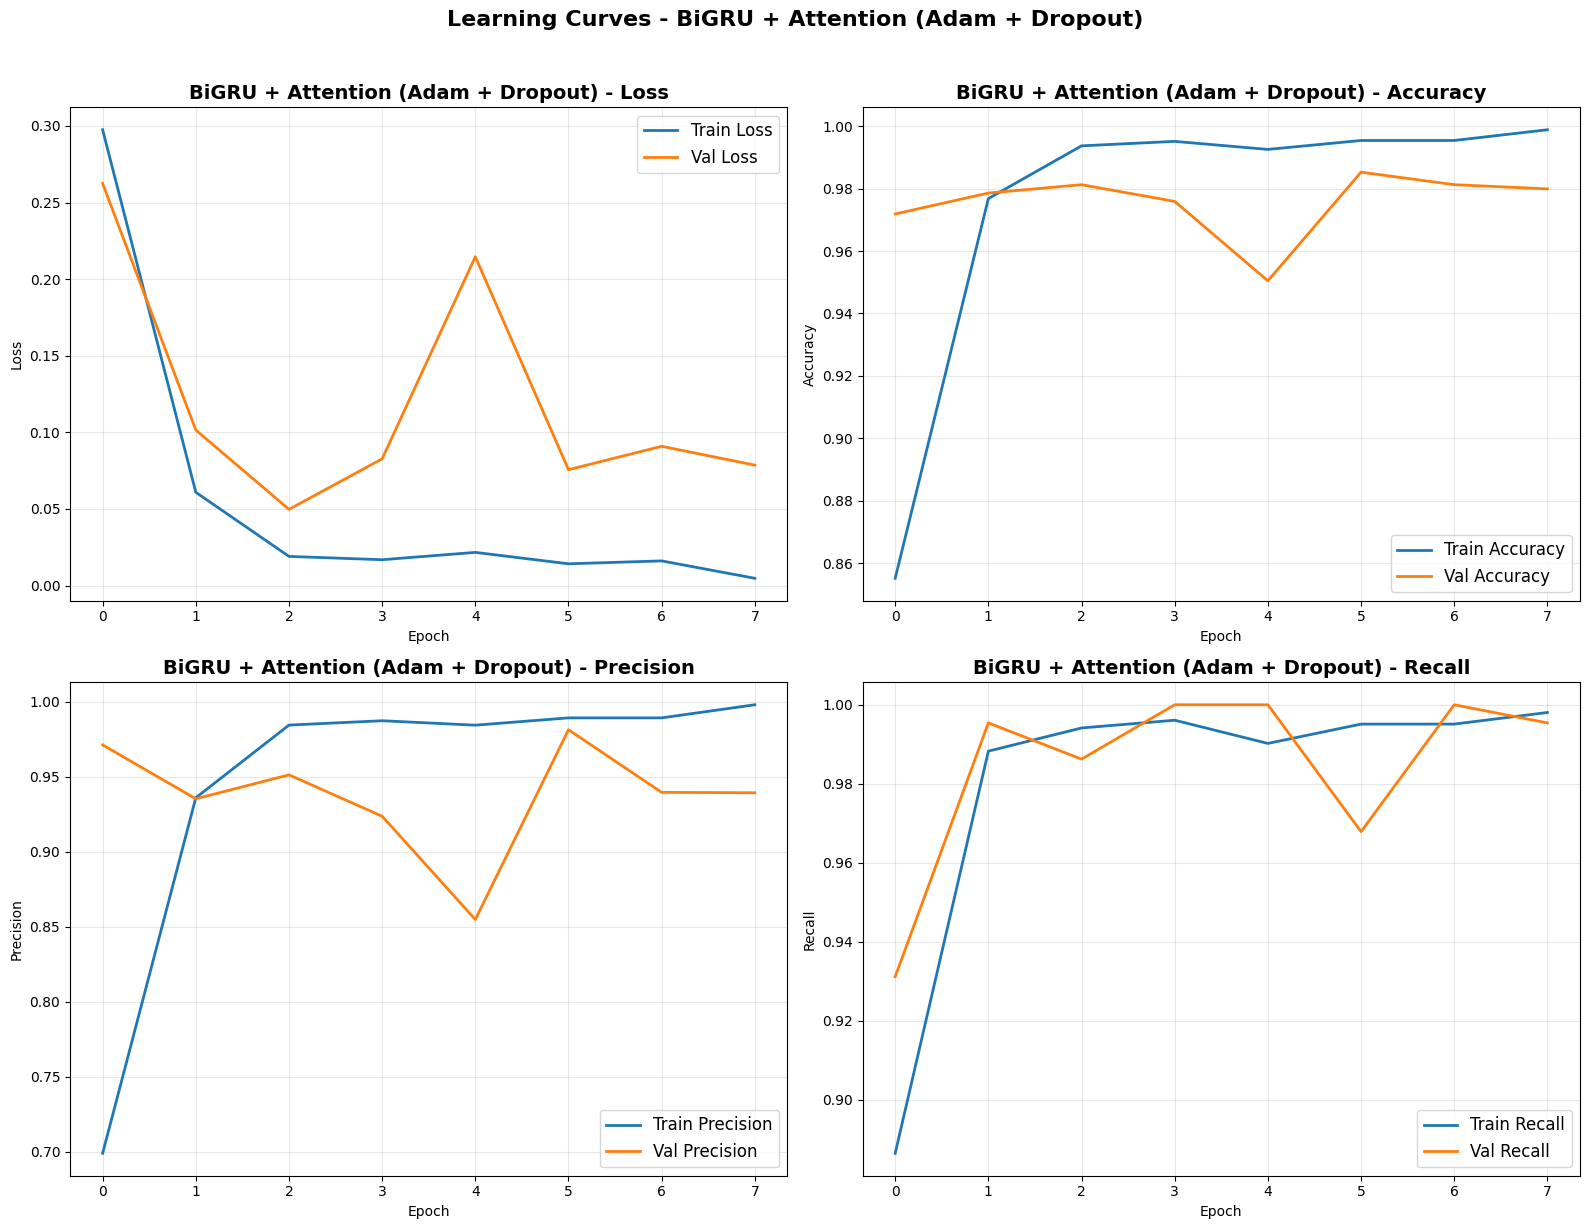


📊 ĐÁNH GIÁ BiGRU + Attention TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9981    0.9755    0.9866       530
    Spam (1)     0.9437    0.9954    0.9689       219

    accuracy                         0.9813       749
   macro avg     0.9709    0.9855    0.9778       749
weighted avg     0.9822    0.9813    0.9815       749

📌 Accuracy : 0.9813
📌 Precision: 0.9437
📌 Recall   : 0.9954  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9689


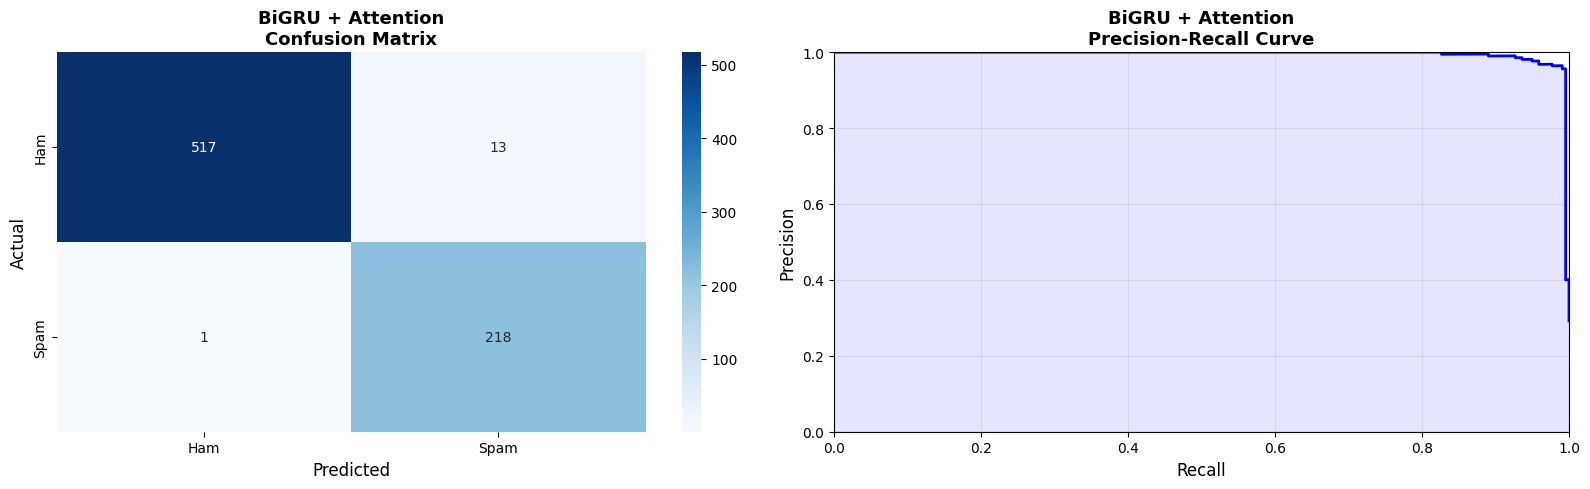

In [ ]:
# ============================================================
# PHẦN 14: HUẤN LUYỆN MÔ HÌNH 2 - BiGRU + Attention
# ============================================================

print("=" * 60)
print("🚀 HUẤN LUYỆN MÔ HÌNH 2: BiGRU + Attention (Adam + Dropout)")
print("=" * 60)

BIGRU_MODEL_PATH = os.path.join(SAVE_DIR, 'bigru_attention.keras')

callbacks_bigru = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BIGRU_MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

history_bigru = model_bigru_att.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_bigru,
    verbose=1
)

print(f"\n✅ Model BiGRU+Attention đã lưu tại: {BIGRU_MODEL_PATH}")

# Vẽ learning curves
plot_learning_curves(history_bigru, 'BiGRU + Attention (Adam + Dropout)',
                     save_path=f'{SAVE_DIR}/learning_curves_bigru_attention.png')

# Đánh giá trên tập test
results_bigru = evaluate_model(model_bigru_att, X_test, y_test, 'BiGRU + Attention',
                                save_path=f'{SAVE_DIR}/eval_bigru_attention.png')

🔬 THÍ NGHIỆM: BiGRU+Attention với SGD
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5522 - loss: 0.7184 - precision: 0.3323 - recall: 0.5463
Epoch 1: val_loss improved from None to 0.58460, saving model to /content/drive/MyDrive/dataset_dl/bigru_attention_sgd.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_dl/bigru_attention_sgd.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.6242 - loss: 0.6528 - precision: 0.4058 - recall: 0.6135 - val_accuracy: 0.8046 - val_loss: 0.5846 - val_precision: 0.6406 - val_recall: 0.7523 - learning_rate: 0.0100
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7989 - loss: 0.4742 - precision: 0.6297 - recall: 0.7312
Epoch 2: val_loss improved from 0.58460 to 0.45217, saving model to /content/drive/MyDrive/dataset_dl/bigru_attention_sgd.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_dl/bigru_attention_sgd.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accurac

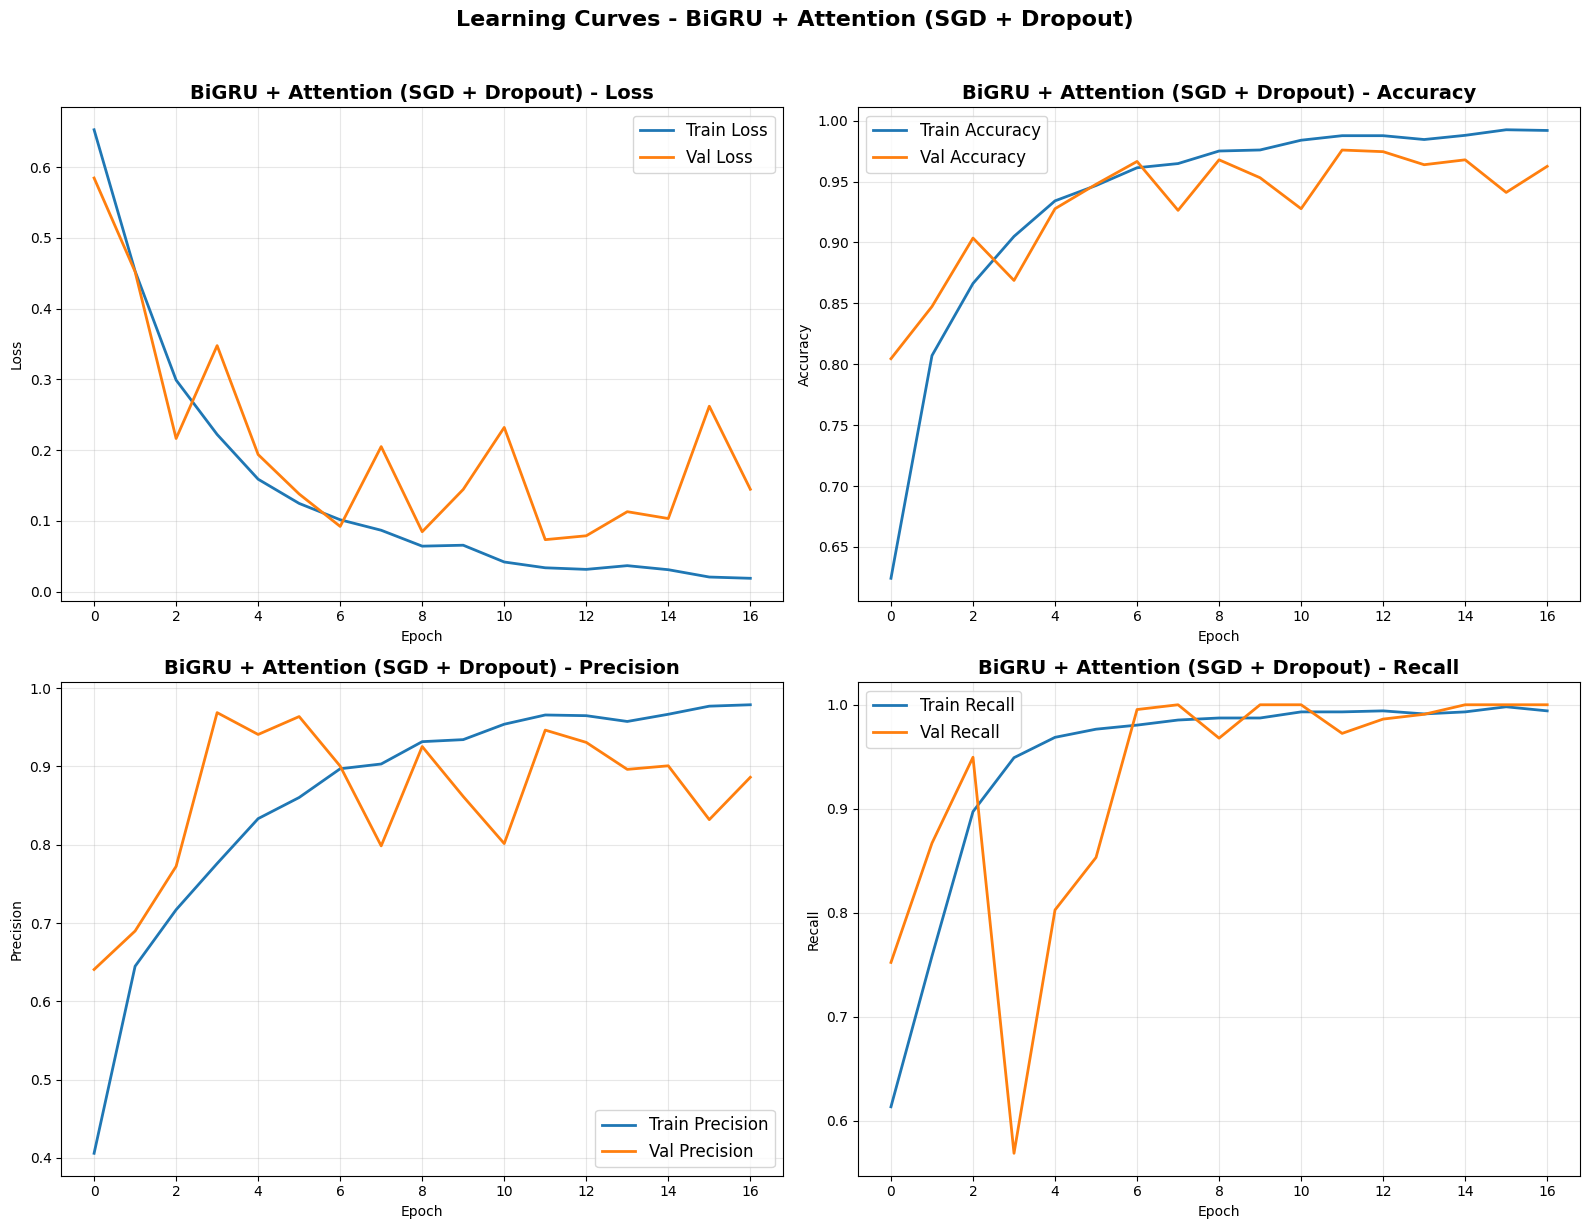


📊 ĐÁNH GIÁ BiGRU+Attention (SGD) TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9924    0.9811    0.9867       530
    Spam (1)     0.9556    0.9817    0.9685       219

    accuracy                         0.9813       749
   macro avg     0.9740    0.9814    0.9776       749
weighted avg     0.9816    0.9813    0.9814       749

📌 Accuracy : 0.9813
📌 Precision: 0.9556
📌 Recall   : 0.9817  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9685


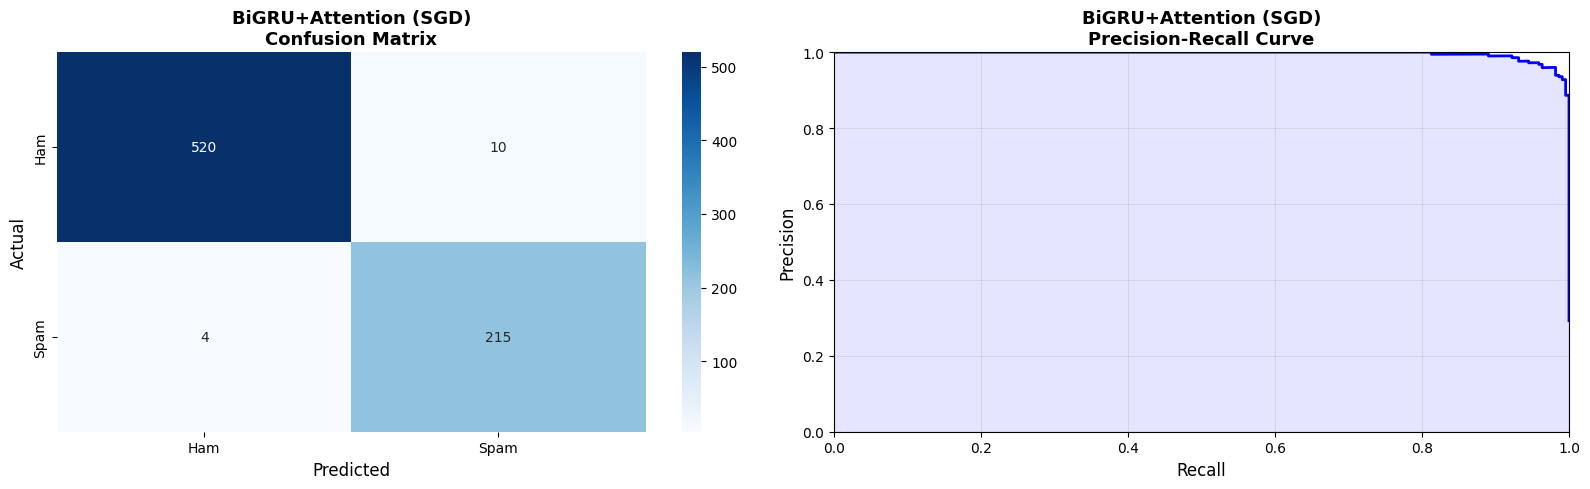


🔬 THÍ NGHIỆM: BiGRU+Attention với Weight Decay
Epoch 1/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7813 - loss: 0.3765 - precision: 0.6022 - recall: 0.8425
Epoch 1: val_loss improved from None to 0.23065, saving model to /content/drive/MyDrive/dataset_dl/bigru_attention_wd.keras

Epoch 1: finished saving model to /content/drive/MyDrive/dataset_dl/bigru_attention_wd.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.8864 - loss: 0.2237 - precision: 0.7494 - recall: 0.9188 - val_accuracy: 0.9398 - val_loss: 0.2307 - val_precision: 0.9887 - val_recall: 0.8028 - learning_rate: 0.0010
Epoch 2/30
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9839 - loss: 0.0454 - precision: 0.9532 - recall: 0.9927
Epoch 2: val_loss improved from 0.23065 to 0.10502, saving model to /content/drive/MyDrive/dataset_dl/bigru_attention_wd.keras

Epoch 2: finished saving model to /content/drive/MyDrive/dataset_dl/bigru_attention_wd.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 257s 2s/step - a

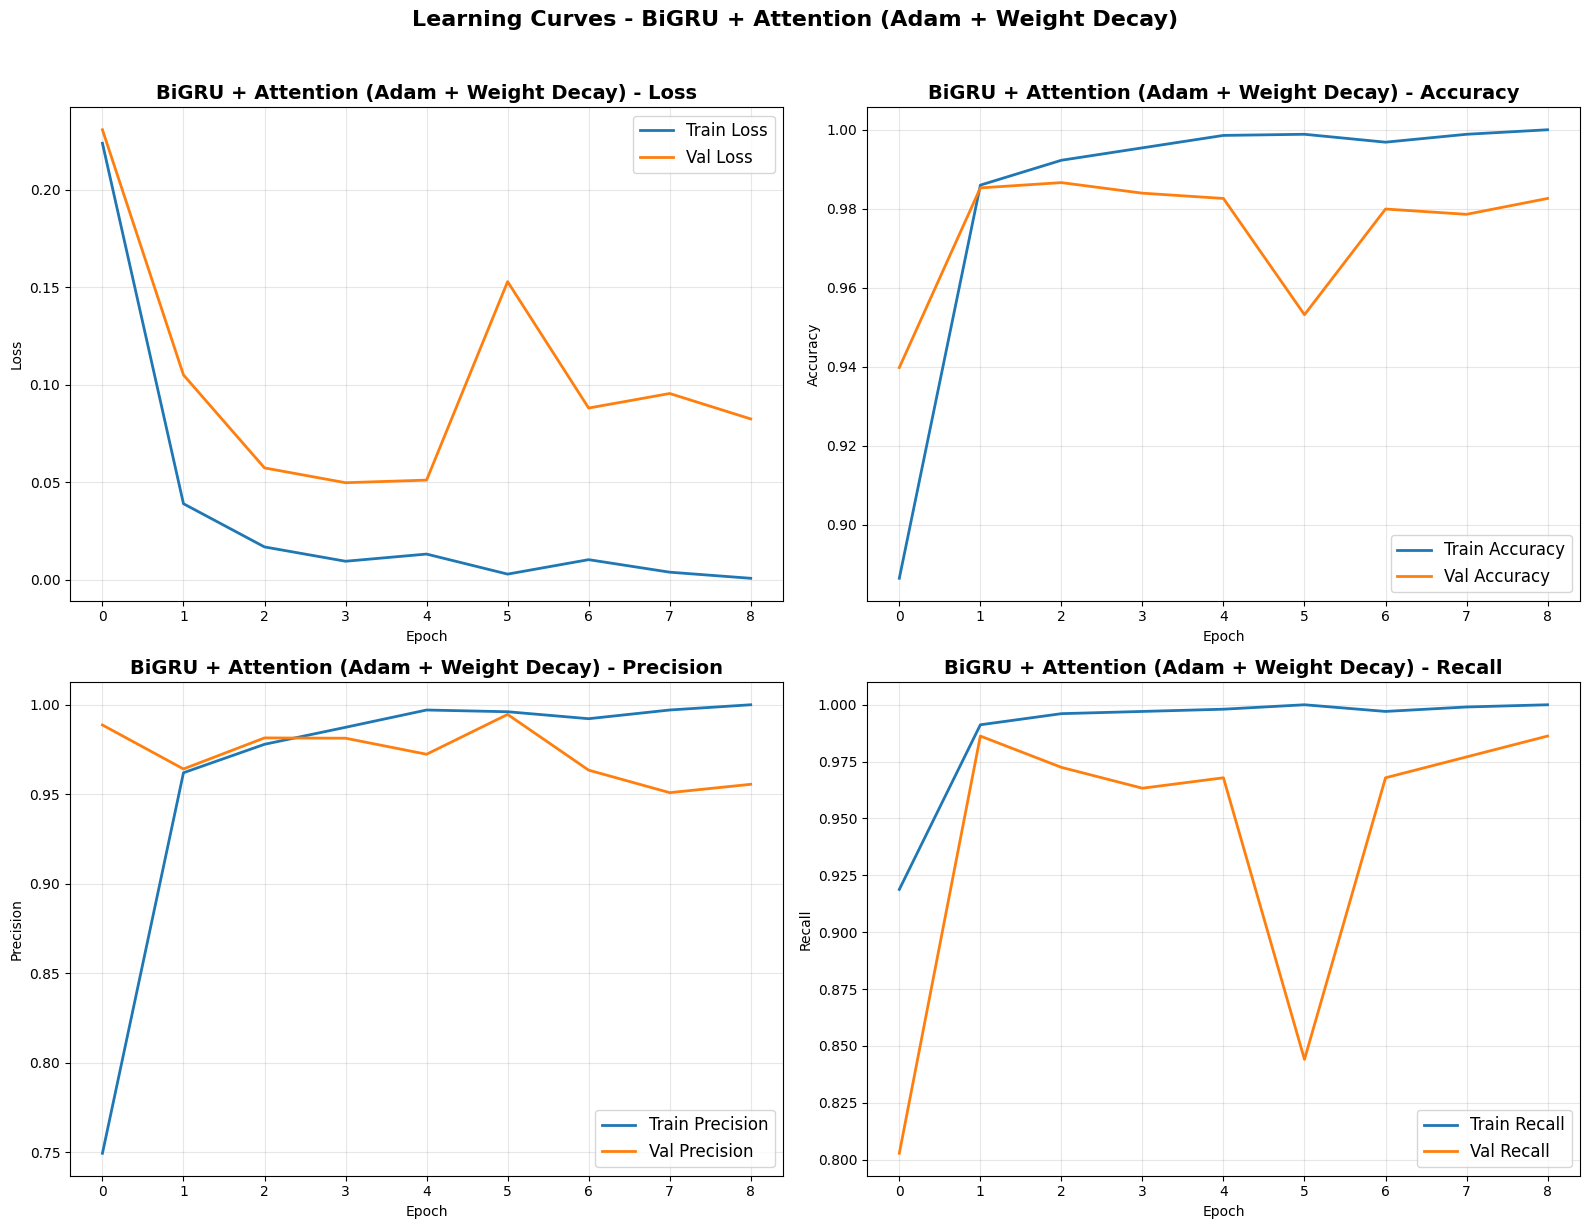


📊 ĐÁNH GIÁ BiGRU+Attention (Weight Decay) TRÊN TẬP TEST

📌 Classification Report:
              precision    recall  f1-score   support

     Ham (0)     0.9906    0.9925    0.9915       530
    Spam (1)     0.9817    0.9772    0.9794       219

    accuracy                         0.9880       749
   macro avg     0.9861    0.9848    0.9855       749
weighted avg     0.9880    0.9880    0.9880       749

📌 Accuracy : 0.9880
📌 Precision: 0.9817
📌 Recall   : 0.9772  ← ƯU TIÊN (phát hiện spam)
📌 F1-Score : 0.9794


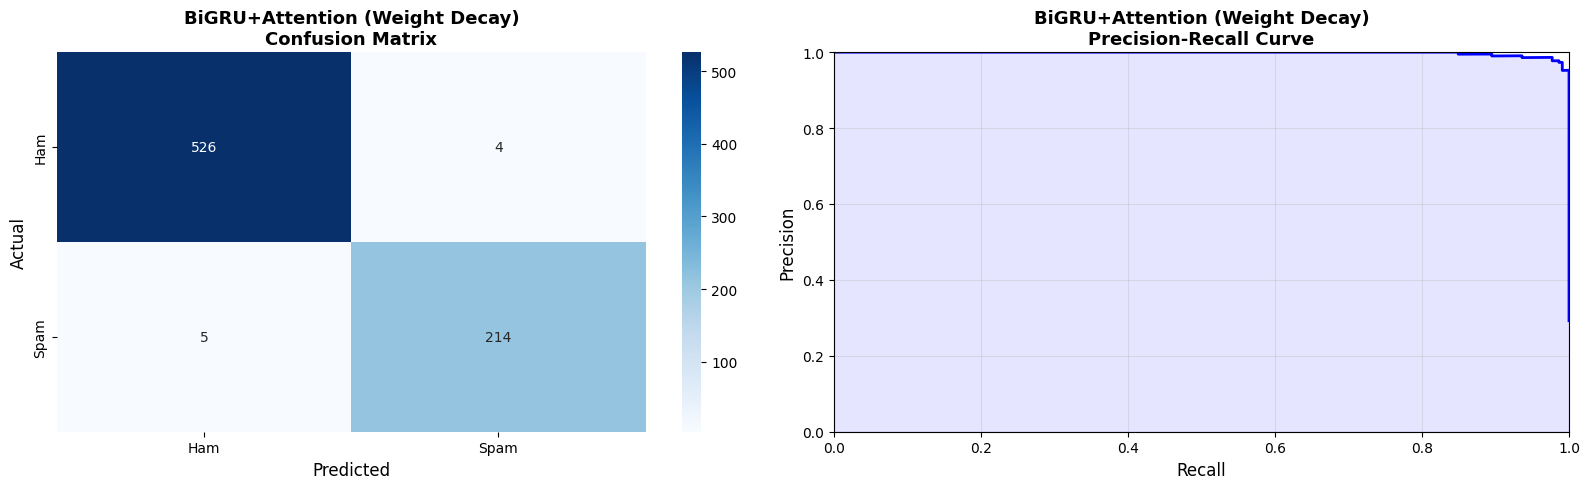

In [16]:
# ============================================================
# PHẦN 15: THÍ NGHIỆM MÔ HÌNH 2 - SGD & WEIGHT DECAY
# ============================================================

# --- Thí nghiệm: BiGRU + Attention với SGD ---
print("=" * 60)
print("🔬 THÍ NGHIỆM: BiGRU+Attention với SGD")
print("=" * 60)

model_bigru_sgd = build_bigru_attention_model(optimizer_name='sgd', dropout_rate=0.5)

BIGRU_SGD_PATH = os.path.join(SAVE_DIR, 'bigru_attention_sgd.keras')
callbacks_bigru_sgd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BIGRU_SGD_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

history_bigru_sgd = model_bigru_sgd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_bigru_sgd,
    verbose=1
)

plot_learning_curves(history_bigru_sgd, 'BiGRU + Attention (SGD + Dropout)',
                     save_path=f'{SAVE_DIR}/learning_curves_bigru_sgd.png')
results_bigru_sgd = evaluate_model(model_bigru_sgd, X_test, y_test, 'BiGRU+Attention (SGD)',
                                    save_path=f'{SAVE_DIR}/eval_bigru_sgd.png')

# --- Thí nghiệm: BiGRU + Attention với Weight Decay ---
print("\n" + "=" * 60)
print("🔬 THÍ NGHIỆM: BiGRU+Attention với Weight Decay")
print("=" * 60)

model_bigru_wd = build_bigru_attention_model(optimizer_name='adam', dropout_rate=0.0, use_weight_decay=True)

BIGRU_WD_PATH = os.path.join(SAVE_DIR, 'bigru_attention_wd.keras')
callbacks_bigru_wd = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(BIGRU_WD_PATH, monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

history_bigru_wd = model_bigru_wd.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks_bigru_wd,
    verbose=1
)

plot_learning_curves(history_bigru_wd, 'BiGRU + Attention (Adam + Weight Decay)',
                     save_path=f'{SAVE_DIR}/learning_curves_bigru_wd.png')
results_bigru_wd = evaluate_model(model_bigru_wd, X_test, y_test, 'BiGRU+Attention (Weight Decay)',
                                   save_path=f'{SAVE_DIR}/eval_bigru_wd.png')

## TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH

📊 BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH VÀ THÍ NGHIỆM
                         Mô hình     Loại  Accuracy  Precision  Recall (Spam)  F1-Score
         BiLSTM (Adam + Dropout) Baseline    0.9893     0.9689         0.9954    0.9820
          BiLSTM (SGD + Dropout) Baseline    0.9866     0.9644         0.9909    0.9775
    BiLSTM (Adam + Weight Decay) Baseline    0.9866     0.9604         0.9954    0.9776
     BiGRU+Attn (Adam + Dropout) Nâng cao    0.9813     0.9437         0.9954    0.9689
      BiGRU+Attn (SGD + Dropout) Nâng cao    0.9813     0.9556         0.9817    0.9685
BiGRU+Attn (Adam + Weight Decay) Nâng cao    0.9880     0.9817         0.9772    0.9794

🏆 Mô hình tốt nhất theo Recall (Spam): BiLSTM (Adam + Dropout)
🏆 Mô hình tốt nhất theo F1-Score:       BiLSTM (Adam + Dropout)


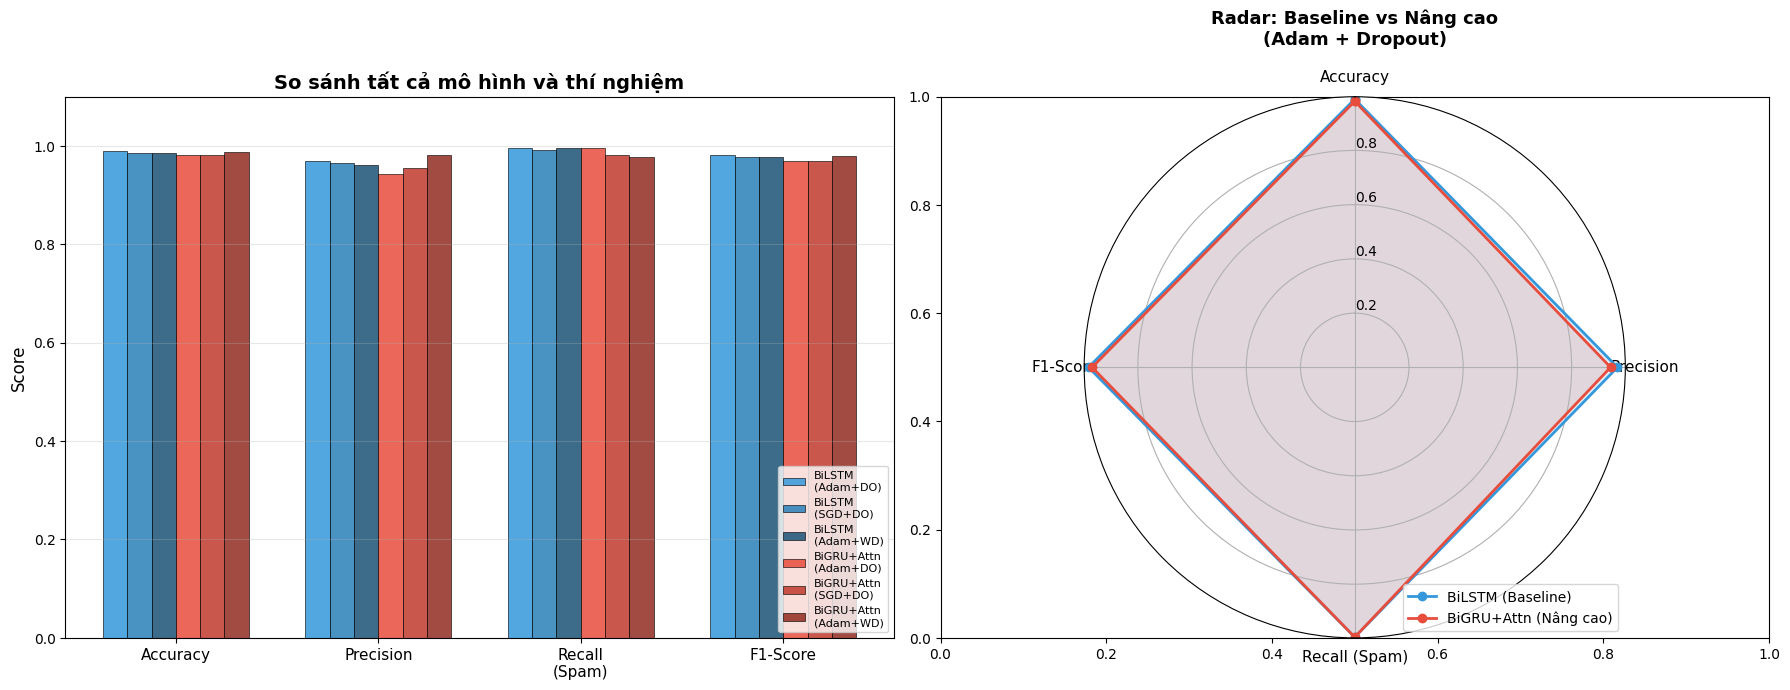


✅ Kết quả đã lưu tại: /content/drive/MyDrive/dataset_dl/experiment_results.csv


In [17]:
# ============================================================
# PHẦN 16: BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH
# ============================================================

print("=" * 70)
print("📊 BẢNG TỔNG HỢP SO SÁNH TẤT CẢ CÁC MÔ HÌNH VÀ THÍ NGHIỆM")
print("=" * 70)

all_results = pd.DataFrame({
    'Mô hình': [
        'BiLSTM (Adam + Dropout)',
        'BiLSTM (SGD + Dropout)',
        'BiLSTM (Adam + Weight Decay)',
        'BiGRU+Attn (Adam + Dropout)',
        'BiGRU+Attn (SGD + Dropout)',
        'BiGRU+Attn (Adam + Weight Decay)',
    ],
    'Loại': ['Baseline', 'Baseline', 'Baseline', 'Nâng cao', 'Nâng cao', 'Nâng cao'],
    'Accuracy': [
        results_bilstm['accuracy'], results_bilstm_sgd['accuracy'], results_bilstm_wd['accuracy'],
        results_bigru['accuracy'], results_bigru_sgd['accuracy'], results_bigru_wd['accuracy']
    ],
    'Precision': [
        results_bilstm['precision'], results_bilstm_sgd['precision'], results_bilstm_wd['precision'],
        results_bigru['precision'], results_bigru_sgd['precision'], results_bigru_wd['precision']
    ],
    'Recall (Spam)': [
        results_bilstm['recall'], results_bilstm_sgd['recall'], results_bilstm_wd['recall'],
        results_bigru['recall'], results_bigru_sgd['recall'], results_bigru_wd['recall']
    ],
    'F1-Score': [
        results_bilstm['f1'], results_bilstm_sgd['f1'], results_bilstm_wd['f1'],
        results_bigru['f1'], results_bigru_sgd['f1'], results_bigru_wd['f1']
    ],
})

# Tìm best model
best_idx_recall = all_results['Recall (Spam)'].idxmax()
best_idx_f1 = all_results['F1-Score'].idxmax()

print(all_results.to_string(index=False, float_format='{:.4f}'.format))
print(f"\n🏆 Mô hình tốt nhất theo Recall (Spam): {all_results.iloc[best_idx_recall]['Mô hình']}")
print(f"🏆 Mô hình tốt nhất theo F1-Score:       {all_results.iloc[best_idx_f1]['Mô hình']}")

# Biểu đồ tổng hợp
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Grouped bar chart - Baseline vs Advanced
metrics_names = ['Accuracy', 'Precision', 'Recall\n(Spam)', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.12

colors_all = ['#3498db', '#2980b9', '#1a5276', '#e74c3c', '#c0392b', '#922b21']
model_names_short = ['BiLSTM\n(Adam+DO)', 'BiLSTM\n(SGD+DO)', 'BiLSTM\n(Adam+WD)',
                      'BiGRU+Attn\n(Adam+DO)', 'BiGRU+Attn\n(SGD+DO)', 'BiGRU+Attn\n(Adam+WD)']

for i, (_, row) in enumerate(all_results.iterrows()):
    vals = [row['Accuracy'], row['Precision'], row['Recall (Spam)'], row['F1-Score']]
    axes[0].bar(x + (i - 2.5) * width, vals, width, label=model_names_short[i],
                color=colors_all[i], alpha=0.85, edgecolor='black', linewidth=0.5)

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('So sánh tất cả mô hình và thí nghiệm', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, fontsize=11)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_ylim(0, 1.1)
axes[0].grid(True, alpha=0.3, axis='y')

# Radar chart (Spider chart) - Top models
from matplotlib.patches import FancyBboxPatch
best_baseline_results = [results_bilstm['accuracy'], results_bilstm['precision'],
                          results_bilstm['recall'], results_bilstm['f1']]
best_advanced_results = [results_bigru['accuracy'], results_bigru['precision'],
                          results_bigru['recall'], results_bigru['f1']]

categories = ['Accuracy', 'Precision', 'Recall (Spam)', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

best_baseline_results += best_baseline_results[:1]
best_advanced_results += best_advanced_results[:1]

ax_radar = axes[1]
ax_radar = fig.add_subplot(122, polar=True)
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_rlabel_position(0)

ax_radar.plot(angles, best_baseline_results, 'o-', linewidth=2, label='BiLSTM (Baseline)', color='#3498db')
ax_radar.fill(angles, best_baseline_results, alpha=0.15, color='#3498db')
ax_radar.plot(angles, best_advanced_results, 'o-', linewidth=2, label='BiGRU+Attn (Nâng cao)', color='#e74c3c')
ax_radar.fill(angles, best_advanced_results, alpha=0.15, color='#e74c3c')

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(categories, fontsize=11)
ax_radar.set_title('Radar: Baseline vs Nâng cao\n(Adam + Dropout)', fontsize=13, fontweight='bold', y=1.08)
ax_radar.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/final_comparison_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

# Lưu kết quả ra CSV
all_results.to_csv(f'{SAVE_DIR}/experiment_results.csv', index=False)
print(f"\n✅ Kết quả đã lưu tại: {SAVE_DIR}/experiment_results.csv")

## LƯU & LOAD MODEL

In [18]:
# ============================================================
# PHẦN 17: LƯU VÀ LOAD MODEL (GOOGLE DRIVE)
# ============================================================

print("=" * 60)
print("💾 LƯU VÀ LOAD MODEL")
print("=" * 60)

# 17.1 Lưu model tốt nhất
# (Chọn model có Recall spam cao nhất hoặc F1 cao nhất)
BEST_MODEL_PATH = os.path.join(SAVE_DIR, 'spam_model.keras')

# Lưu model BiGRU+Attention (mô hình nâng cao) làm model chính
model_bigru_att.save(BEST_MODEL_PATH)
print(f"✅ Model tốt nhất đã lưu tại: {BEST_MODEL_PATH}")

# 17.2 Kiểm tra tất cả files đã lưu
print(f"\n📁 Danh sách files trong {SAVE_DIR}:")
for f in sorted(os.listdir(SAVE_DIR)):
    filepath = os.path.join(SAVE_DIR, f)
    size = os.path.getsize(filepath) / (1024 * 1024)  # MB
    print(f"   📄 {f} ({size:.2f} MB)")

# 17.3 Demo LOAD model (không cần train lại)
print(f"\n{'='*60}")
print("🔄 DEMO: LOAD MODEL TỪ GOOGLE DRIVE")
print("=" * 60)

# Load model
loaded_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={'AttentionLayer': AttentionLayer}
)
print(f"✅ Đã load model từ: {BEST_MODEL_PATH}")
print(f"📌 Model name: {loaded_model.name}")

# Load tokenizer
with open(os.path.join(SAVE_DIR, 'tokenizer.pickle'), 'rb') as f:
    loaded_tokenizer = pickle.load(f)
print(f"✅ Đã load tokenizer")

# Verify - đánh giá lại trên test set
y_pred_loaded = (loaded_model.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
acc_loaded = accuracy_score(y_test, y_pred_loaded)
print(f"\n📌 Verification: Accuracy trên test set = {acc_loaded:.4f}")
print("✅ Model hoạt động chính xác sau khi load!")

💾 LƯU VÀ LOAD MODEL
✅ Model tốt nhất đã lưu tại: /content/drive/MyDrive/dataset_dl/spam_model.keras

📁 Danh sách files trong /content/drive/MyDrive/dataset_dl:
   📄 BCCD Dataset with mask (0.00 MB)
   📄 YoutubeCommentsDataSet.csv (3.33 MB)
   📄 bigru_attention.keras (33.74 MB)
   📄 bigru_attention_sgd.keras (22.51 MB)
   📄 bigru_attention_wd.keras (33.74 MB)
   📄 bilstm_baseline.keras (32.58 MB)
   📄 bilstm_sgd.keras (21.73 MB)
   📄 bilstm_weight_decay.keras (32.58 MB)
   📄 cifar10 (0.00 MB)
   📄 class_distribution.png (0.07 MB)
   📄 comparison_experiments_baseline.png (0.06 MB)
   📄 distilbert_sentiment_model.pt (255.46 MB)
   📄 enron_spam_data.csv (54.17 MB)
   📄 eval_bigru_attention.png (0.06 MB)
   📄 eval_bigru_sgd.png (0.06 MB)
   📄 eval_bigru_wd.png (0.06 MB)
   📄 eval_bilstm.png (0.06 MB)
   📄 eval_bilstm_sgd.png (0.06 MB)
   📄 eval_bilstm_wd.png (0.06 MB)
   📄 experiment_results.csv (0.00 MB)
   📄 final_comparison_all_models.png (0.25 MB)
   📄 learning_curves_bigru_attention.pn

## Demo

In [22]:
# ============================================================
# PHẦN 18: DEMO TƯƠNG TÁC - PHÁT HIỆN SPAM EMAIL
# ============================================================

print("=" * 60)
print("🎯 DEMO: PHÁT HIỆN SPAM EMAIL REAL-TIME")
print("=" * 60)

# --- Nếu cần load model (chạy riêng cell này mà không train lại) ---
import os
import pickle
import re
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences

SAVE_DIR = '/content/drive/MyDrive/dataset_dl'
MAX_LEN = 256

# Định nghĩa lại AttentionLayer (cần thiết khi load model)
class AttentionLayer(keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight',
                                 shape=(input_shape[-1], input_shape[-1]),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='attention_bias',
                                 shape=(input_shape[-1],),
                                 initializer='zeros', trainable=True)
        self.u = self.add_weight(name='context_vector',
                                 shape=(input_shape[-1],),
                                 initializer='glorot_uniform', trainable=True)
        super(AttentionLayer, self).build(input_shape)
    def call(self, x):
        u_it = tf.nn.tanh(tf.tensordot(x, self.W, axes=1) + self.b)
        a_it = tf.nn.softmax(tf.tensordot(u_it, self.u, axes=1), axis=1)
        a_it = tf.expand_dims(a_it, -1)
        return tf.reduce_sum(x * a_it, axis=1)
    def get_config(self):
        return super(AttentionLayer, self).get_config()

# Load model và tokenizer
model = keras.models.load_model(
    os.path.join(SAVE_DIR, 'spam_model.keras'),
    custom_objects={'AttentionLayer': AttentionLayer}
)
with open(os.path.join(SAVE_DIR, 'tokenizer.pickle'), 'rb') as f:
    tokenizer = pickle.load(f)

print("✅ Model và Tokenizer đã được load thành công!")

# --- Hàm tiền xử lý (giống lúc train) ---
def preprocess_email(text):
    if not text:
        return ""
    text = str(text)
    text = re.sub(r'^Subject:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http[s]?://\S+', ' ', text)
    text = re.sub(r'www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --- Hàm dự đoán ---
def predict_spam(email_text, threshold=0.5):
    """
    Dự đoán email là Spam hay Ham

    Parameters:
    - email_text: Nội dung email (string)
    - threshold: Ngưỡng phân loại (mặc định 0.5)

    Returns:
    - Kết quả phân loại và xác suất
    """
    # Tiền xử lý
    clean_text = preprocess_email(email_text)

    # Tokenize
    sequence = tokenizer.texts_to_sequences([clean_text])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict
    prob = model.predict(padded, verbose=0)[0][0]

    # Kết quả
    label = "🚨 SPAM" if prob >= threshold else "✅ HAM (Không phải spam)"
    confidence = prob if prob >= threshold else 1 - prob

    print(f"\n{'='*60}")
    print(f"📧 KẾT QUẢ PHÂN LOẠI EMAIL")
    print(f"{'='*60}")
    print(f"📌 Kết quả  : {label}")
    print(f"📌 Xác suất spam: {prob:.4f} ({prob*100:.2f}%)")
    print(f"📌 Độ tin cậy   : {confidence:.4f} ({confidence*100:.2f}%)")
    print(f"📌 Ngưỡng       : {threshold}")
    print(f"{'='*60}")

    return label, prob

# --- Demo với các email mẫu ---
print("\n" + "="*60)
print("📧 DEMO VỚI CÁC EMAIL MẪU")
print("="*60)

sample_emails = [
    # Spam samples
    "Subject: Congratulations! You've won $1,000,000! Click here to claim your prize now! Limited time offer!",
    "Subject: URGENT: Your account will be suspended. Verify your password immediately at http://fake-bank.com",
    "Subject: Buy cheap viagra, cialis online. Best prices guaranteed! Order now and get free shipping!",
    "Subject: Make money fast! Work from home and earn $5000 per week. No experience needed!",

    # Ham samples
    "Subject: Meeting tomorrow Hi team, just a reminder that we have a project meeting tomorrow at 10am in conference room B. Please bring your progress reports.",
    "Subject: Re: Quarterly Report Please find attached the quarterly financial report. Let me know if you have any questions about the figures.",
    "Subject: Lunch plans Hey, are you free for lunch today? I was thinking we could try that new Italian place downtown.",
    "Subject: hpl nom for january 9 2001 see attached file hplnol 09 xls",
]

for i, email in enumerate(sample_emails):
    print(f"\n{'─'*60}")
    print(f"📧 Email #{i+1}:")
    print(f"   {email[:100]}{'...' if len(email) > 100 else ''}")
    predict_spam(email)

🎯 DEMO: PHÁT HIỆN SPAM EMAIL REAL-TIME
✅ Model và Tokenizer đã được load thành công!

📧 DEMO VỚI CÁC EMAIL MẪU

────────────────────────────────────────────────────────────
📧 Email #1:
   Subject: Congratulations! You've won $1,000,000! Click here to claim your prize now! Limited time of...

📧 KẾT QUẢ PHÂN LOẠI EMAIL
📌 Kết quả  : 🚨 SPAM
📌 Xác suất spam: 0.9997 (99.97%)
📌 Độ tin cậy   : 0.9997 (99.97%)
📌 Ngưỡng       : 0.5

────────────────────────────────────────────────────────────
📧 Email #2:
   Subject: URGENT: Your account will be suspended. Verify your password immediately at http://fake-ban...

📧 KẾT QUẢ PHÂN LOẠI EMAIL
📌 Kết quả  : 🚨 SPAM
📌 Xác suất spam: 0.6859 (68.59%)
📌 Độ tin cậy   : 0.6859 (68.59%)
📌 Ngưỡng       : 0.5

────────────────────────────────────────────────────────────
📧 Email #3:
   Subject: Buy cheap viagra, cialis online. Best prices guaranteed! Order now and get free shipping!

📧 KẾT QUẢ PHÂN LOẠI EMAIL
📌 Kết quả  : 🚨 SPAM
📌 Xác suất spam: 1.0000 (100.00%)
📌 

In [23]:
# ============================================================
# PHẦN 19: DEMO TƯƠNG TÁC - NHẬP EMAIL TỪ BÀN PHÍM
# ============================================================

print("=" * 60)
print("🎮 DEMO TƯƠNG TÁC: NHẬP EMAIL ĐỂ PHÂN LOẠI")
print("=" * 60)
print("📌 Nhập nội dung email để kiểm tra spam/ham")
print("📌 Nhập 'quit' hoặc 'exit' để thoát\n")

while True:
    email_input = input("📧 Nhập nội dung email (hoặc 'quit' để thoát): \n")

    if email_input.lower().strip() in ['quit', 'exit', 'q']:
        print("\n👋 Cảm ơn đã sử dụng! Goodbye!")
        break

    if len(email_input.strip()) == 0:
        print("⚠️  Email rỗng! Vui lòng nhập nội dung.\n")
        continue

    predict_spam(email_input)
    print()

🎮 DEMO TƯƠNG TÁC: NHẬP EMAIL ĐỂ PHÂN LOẠI
📌 Nhập nội dung email để kiểm tra spam/ham
📌 Nhập 'quit' hoặc 'exit' để thoát

📧 Nhập nội dung email (hoặc 'quit' để thoát): 
Subject: Congratulations! You've won $1,000,000! Click here to claim your prize now! Limited time offer!

📧 KẾT QUẢ PHÂN LOẠI EMAIL
📌 Kết quả  : 🚨 SPAM
📌 Xác suất spam: 0.9997 (99.97%)
📌 Độ tin cậy   : 0.9997 (99.97%)
📌 Ngưỡng       : 0.5

📧 Nhập nội dung email (hoặc 'quit' để thoát): 
Dear Customer,  This is a reminder that your outstanding balance of $1,299.00 is due for the recent purchase made on your account.  If you believe this charge is incorrect, please review the transaction details and contact us immediately. Otherwise, payment must be completed within 48 hours to avoid additional fees.  You can make your payment securely using the link below: [Pay Now]  Thank you for your prompt attention to this matter.  Sincerely, Billing Department

📧 KẾT QUẢ PHÂN LOẠI EMAIL
📌 Kết quả  : 🚨 SPAM
📌 Xác suất spam: 0.9299 (92.

## PHÂN TÍCH LỖI ĐIỂN HÌNH

🔍 PHÂN TÍCH LỖI ĐIỂN HÌNH

📌 Tổng mẫu test: 749
📌 Số mẫu phân loại sai: 14 (1.87%)

📌 False Positives (Ham → Spam): 13
📌 False Negatives (Spam → Ham): 1


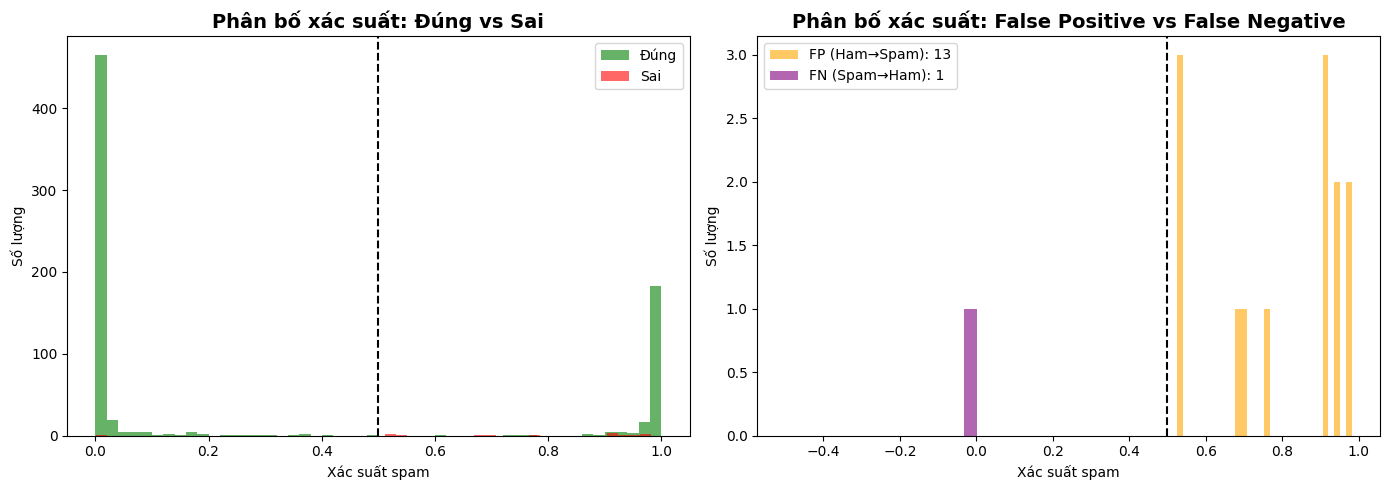


📌 Một số mẫu FALSE NEGATIVE (Spam bị nhầm là Ham) - NGUY HIỂM:
  [1] Prob=0.0019 | <OOV> frauen in lack und leder gefesselt geknebelt und bdsm wachs und fisting hier findest du alles perverse videogalerien mit hunderten von filmen aus allen sparten und e bilder in...

📌 Nhận xét:
  • False Negatives (spam lọt qua) nguy hiểm hơn False Positives
  • Các spam email bị nhầm thường có xác suất gần ngưỡng 0.5
  • Có thể điều chỉnh threshold < 0.5 để tăng Recall spam


In [21]:
# ============================================================
# PHẦN 20: PHÂN TÍCH LỖI ĐIỂN HÌNH (Error Analysis)
# ============================================================

print("=" * 60)
print("🔍 PHÂN TÍCH LỖI ĐIỂN HÌNH")
print("=" * 60)

# Lấy dữ liệu test gốc
test_indices = df_clean.index[-len(y_test):]  # Approximate

# Predict trên test set
y_pred_prob_test = model_bigru_att.predict(X_test, verbose=0).flatten()
y_pred_test = (y_pred_prob_test >= 0.5).astype(int)

# Tìm các mẫu phân loại sai
errors = np.where(y_pred_test != y_test)[0]
print(f"\n📌 Tổng mẫu test: {len(y_test)}")
print(f"📌 Số mẫu phân loại sai: {len(errors)} ({len(errors)/len(y_test)*100:.2f}%)")

# False Positives (Ham bị nhầm là Spam)
fp_indices = errors[y_test[errors] == 0]
# False Negatives (Spam bị nhầm là Ham)
fn_indices = errors[y_test[errors] == 1]

print(f"\n📌 False Positives (Ham → Spam): {len(fp_indices)}")
print(f"📌 False Negatives (Spam → Ham): {len(fn_indices)}")

# Phân bố xác suất dự đoán
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Phân bố cho đúng vs sai
correct = np.where(y_pred_test == y_test)[0]
axes[0].hist(y_pred_prob_test[correct], bins=50, alpha=0.6, label='Đúng', color='green')
axes[0].hist(y_pred_prob_test[errors], bins=50, alpha=0.6, label='Sai', color='red')
axes[0].set_title('Phân bố xác suất: Đúng vs Sai', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Xác suất spam')
axes[0].set_ylabel('Số lượng')
axes[0].legend()
axes[0].axvline(x=0.5, color='black', linestyle='--')

# Phân bố cho FP vs FN
if len(fp_indices) > 0:
    axes[1].hist(y_pred_prob_test[fp_indices], bins=30, alpha=0.6,
                 label=f'FP (Ham→Spam): {len(fp_indices)}', color='orange')
if len(fn_indices) > 0:
    axes[1].hist(y_pred_prob_test[fn_indices], bins=30, alpha=0.6,
                 label=f'FN (Spam→Ham): {len(fn_indices)}', color='purple')
axes[1].set_title('Phân bố xác suất: False Positive vs False Negative', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Xác suất spam')
axes[1].set_ylabel('Số lượng')
axes[1].legend()
axes[1].axvline(x=0.5, color='black', linestyle='--')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Hiển thị một số mẫu sai
print("\n📌 Một số mẫu FALSE NEGATIVE (Spam bị nhầm là Ham) - NGUY HIỂM:")
for i, idx in enumerate(fn_indices[:5]):
    seq = X_test[idx]
    words = []
    for token_id in seq:
        if token_id > 0:
            for word, id_ in tokenizer.word_index.items():
                if id_ == token_id:
                    words.append(word)
                    break
    text_preview = ' '.join(words[:30])
    print(f"  [{i+1}] Prob={y_pred_prob_test[idx]:.4f} | {text_preview}...")

print("\n📌 Nhận xét:")
print("  • False Negatives (spam lọt qua) nguy hiểm hơn False Positives")
print("  • Các spam email bị nhầm thường có xác suất gần ngưỡng 0.5")
print("  • Có thể điều chỉnh threshold < 0.5 để tăng Recall spam")